<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Sensitivity_Soil_Nutrient_Pools_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sensitivity Soil Nutrient Pools Dataset

# About the Dataset and Insights

Dataset, titled 'Sensitivity Soil Nutrient Pools,' provides valuable information related to ecological studies, likely focusing on how various factors influence soil nutrient dynamics. Each entry represents a sample (SampleID) taken from different site locations, organized within block, paddock, and plot structures. Key experimental variables include slope, rainfall_reduction, grazing_treatment (heavy, destock, stable), and the year of sampling. A crucial variable, faith_pd, which appears to be a measure of phylogenetic diversity (e.g., related to microbial communities like bacteria or fungi), was initially stored as an object due to formatting but has been successfully converted to a numerical type, allowing for quantitative analysis.

Key Insights from Visualizations:

Data Completeness and Structure: We confirmed the dataset has 1006 entries and no missing values, indicating a robust foundation for analysis. There are two distinct site locations (FK and TB) and two type classifications (bacteria and fungi), which are fairly balanced.

Grazing Treatment Distribution: The grazing_treatment variable shows a relatively even distribution across 'heavy,' 'destock,' and 'stable' categories, suggesting a balanced experimental design concerning grazing impact.

'faith_pd' Distribution: After converting faith_pd to a numerical format, its histogram revealed a distribution of values, which now allows us to understand its spread and central tendency. This was a critical step for further quantitative analysis.

Bivariate Relationships:

Numerical Features: Scatter plots between numerical features like block, paddock, plot, slope, rainfall_reduction, year, and faith_pd (which is now numerical) help us identify potential linear or non-linear relationships. For instance, we can now observe if rainfall_reduction or year show any visible trends with faith_pd.
Categorical vs. Numerical: Box plots effectively illustrate how numerical variables (including the converted faith_pd) vary across different categorical groups (site, grazing_treatment, type). For example, we can compare the range and median of faith_pd between 'bacteria' and 'fungi' types, or across different grazing treatments, to see if there are significant differences.
Correlations: The correlation matrix, now updated to include the numerical faith_pd, provides a quantitative measure of linear relationships between all numerical variables. This helps identify strong positive or negative correlations (e.g., if faith_pd is positively correlated with year or negatively correlated with rainfall_reduction), guiding us towards deeper insights about which factors might influence phylogenetic diversity.

These visualizations collectively offer a foundational understanding of the dataset's characteristics, highlighting distributions, potential relationships, and areas for further investigation.



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [1]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d willianoliveiragibin/sensitivity-soil-nutrient-pools

# Unziping the downloaded file
!unzip sensitivity-soil-nutrient-pools.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/willianoliveiragibin/sensitivity-soil-nutrient-pools
License(s): CC0-1.0
  0% 0.00/12.8k [00:00<?, ?B/s]
100% 12.8k/12.8k [00:00<00:00, 63.4MB/s]
Archive:  sensitivity-soil-nutrient-pools.zip
  inflating: Sensitivity_Soil_Nutrient_Pools new.csv  


In [6]:
df = pd.read_csv('Sensitivity_Soil_Nutrient_Pools new.csv')
df.head(11)

,SampleID,site,block,paddock,plot,slope,rainfall_reduction,grazing_treatment,year,type,faith_pd
0,GMDR-FK-2018-4,FK,1,1,4,4,0,stable,2018,bacteria,3.912.908.739
1,GMDR-TB-2018-45,TB,3,2,45,2,50,heavy,2018,bacteria,3.298.556.468
2,GMDR-TB-2018-8,TB,1,3,8,1,75,destock,2018,bacteria,3.332.257.877
3,GMDR-TB-2018-31,TB,2,3,31,4,99,destock,2018,bacteria,3.806.342.641
4,GMDR-TB-2018-23,TB,2,2,23,6,0,heavy,2018,bacteria,4.135.953.774
5,GMDR-FK-2018-2,FK,1,1,2,4,99,stable,2018,bacteria,3.913.625.786
6,GMDR-FK-2018-13,FK,1,3,13,3,50,destock,2018,bacteria,4.339.569.466
7,GMDR-TB-2018-44,TB,3,2,44,1,25,heavy,2018,bacteria,3.756.680.567
8,GMDR-FK-2018-53,FK,3,3,53,1,0,heavy,2018,bacteria,3.824.880.797
9,GMDR-TB-2018-17,TB,1,1,17,4,0,stable,2018,bacteria,4.110.560.301


In [7]:
df.tail(11)

,SampleID,site,block,paddock,plot,slope,rainfall_reduction,grazing_treatment,year,type,faith_pd
995,GMDR-FK-2022-34,FK,2,3,34,2,0,heavy,2022,fungi,2.467.915.838
996,GMDR-FK-2022-50,FK,3,3,50,3,25,heavy,2022,fungi,2.338.357.199
997,GMDR-TB-2022-47,TB,3,2,47,3,99,heavy,2022,fungi,3.496.162.435
998,GMDR-FK-2022-43,FK,3,2,43,6,0,stable,2022,fungi,2.929.675.494
999,GMDR-FK-2022-46,FK,3,2,46,5,75,stable,2022,fungi,2.885.395.903
1000,GMDR-FK-2022-3,FK,1,1,3,3,0,stable,2022,fungi,2.625.697.879
1001,GMDR-FK-2022-23,FK,2,1,23,1,0,destock,2022,fungi,2.229.139.198
1002,GMDR-FK-2022-20,FK,2,1,20,2,0,destock,2022,fungi,1.572.091.467
1003,GMDR-TB-2022-49,TB,3,1,49,4,50,stable,2022,fungi,3.400.527.221
1004,GMDR-FK-2022-52,FK,3,3,52,2,0,heavy,2022,fungi,1.679.936.128


In [8]:
df.shape

(1006, 11)

In [9]:
df.columns

Index(['SampleID', 'site', 'block', 'paddock', 'plot', 'slope',
       'rainfall_reduction', 'grazing_treatment', 'year', 'type', 'faith_pd'],
      dtype='object')

In [10]:
df.dtypes

,0
SampleID,object
site,object
block,int64
paddock,int64
plot,int64
slope,int64
rainfall_reduction,int64
grazing_treatment,object
year,int64
type,object


In [25]:
# Cleaning and converting 'faith_pd' to numeric
df['faith_pd'] = df['faith_pd'].str.replace('.', '', regex=False).astype(float)

# Displaying the updated data types to confirm the change
print("Updated DataFrame dtypes after converting 'faith_pd':")
display(df.dtypes)

Updated DataFrame dtypes after converting 'faith_pd':


,0
SampleID,object
site,object
block,int64
paddock,int64
plot,int64
slope,int64
rainfall_reduction,int64
grazing_treatment,object
year,int64
type,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SampleID            1006 non-null   object
 1   site                1006 non-null   object
 2   block               1006 non-null   int64 
 3   paddock             1006 non-null   int64 
 4   plot                1006 non-null   int64 
 5   slope               1006 non-null   int64 
 6   rainfall_reduction  1006 non-null   int64 
 7   grazing_treatment   1006 non-null   object
 8   year                1006 non-null   int64 
 9   type                1006 non-null   object
 10  faith_pd            1006 non-null   object
dtypes: int64(6), object(5)
memory usage: 86.6+ KB


In [12]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SampleID,1006,511,GMDR-TB-2022-50,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site,1006,2,FK,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,1006.0,NaN,NaN,NaN,1.997018,0.8171,1.0,1.0,2.0,3.0,3.0
paddock,1006.0,NaN,NaN,NaN,2.005964,0.816475,1.0,1.0,2.0,3.0,3.0
plot,1006.0,NaN,NaN,NaN,27.485089,15.529054,1.0,14.0,27.5,41.0,54.0
slope,1006.0,NaN,NaN,NaN,3.037773,1.569791,1.0,2.0,3.0,4.0,6.0
rainfall_reduction,1006.0,NaN,NaN,NaN,41.16501,36.765529,0.0,0.0,25.0,75.0,99.0
grazing_treatment,1006,3,heavy,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1006.0,NaN,NaN,NaN,2019.930417,1.378993,2018.0,2019.0,2020.0,2021.0,2022.0
type,1006,2,bacteria,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.isnull().sum()

,0
SampleID,0
site,0
block,0
paddock,0
plot,0
slope,0
rainfall_reduction,0
grazing_treatment,0
year,0
type,0


In [14]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

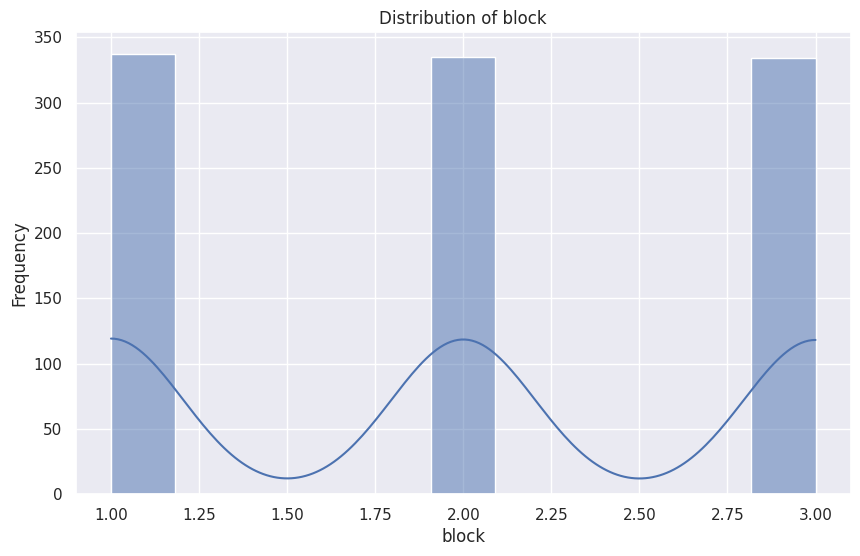

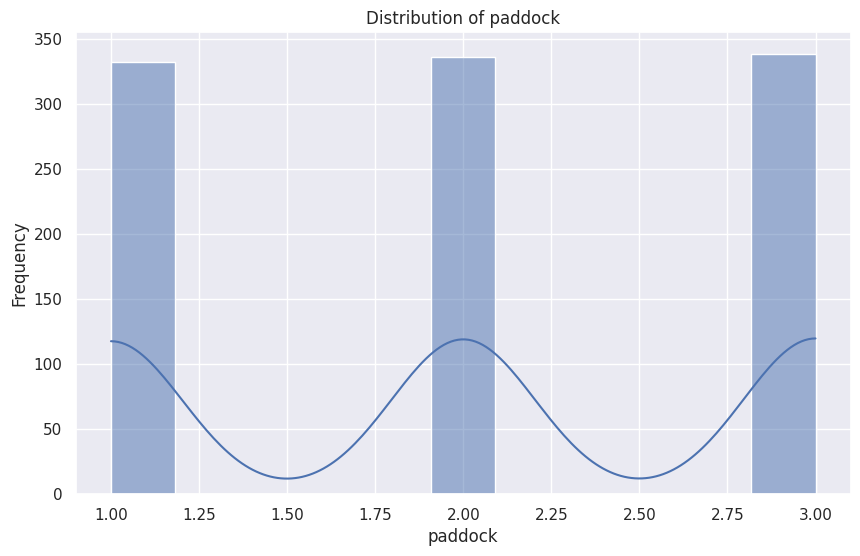

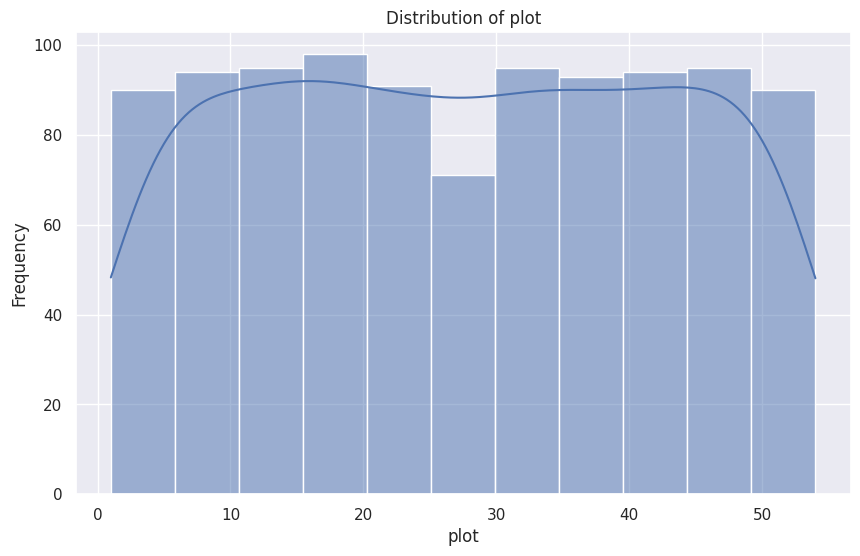

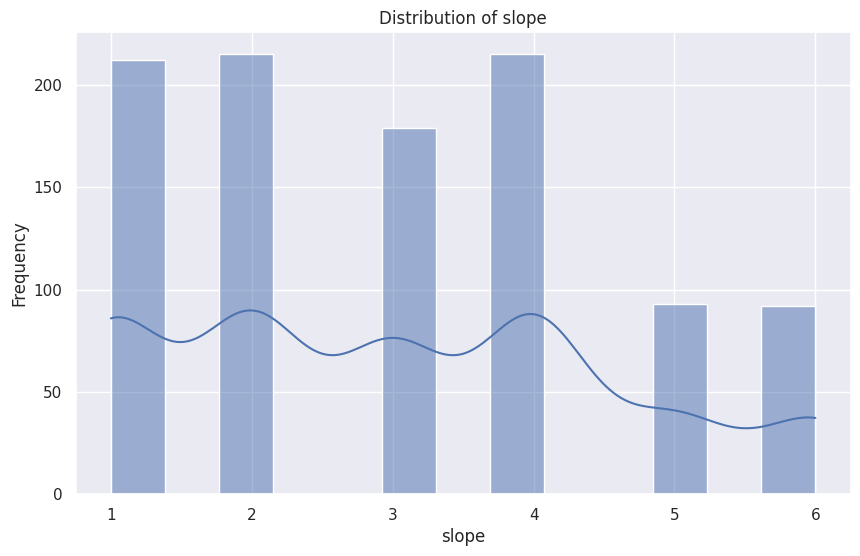

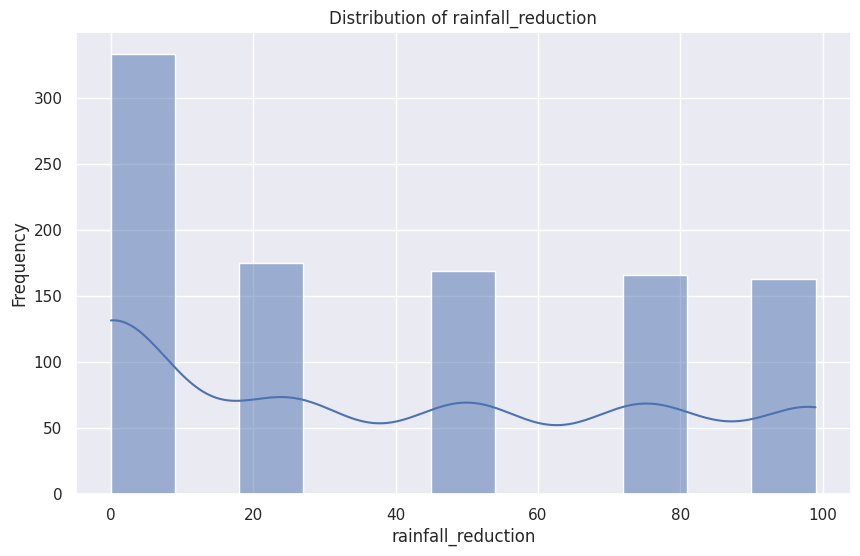

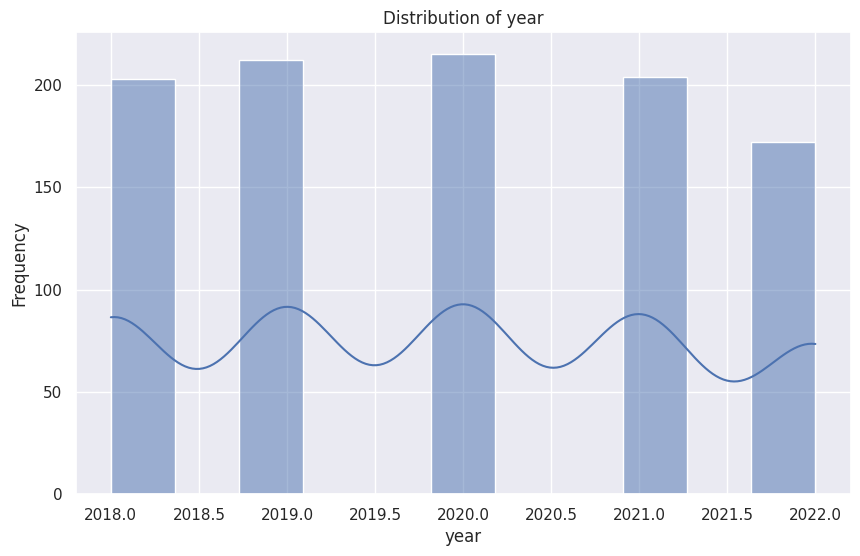

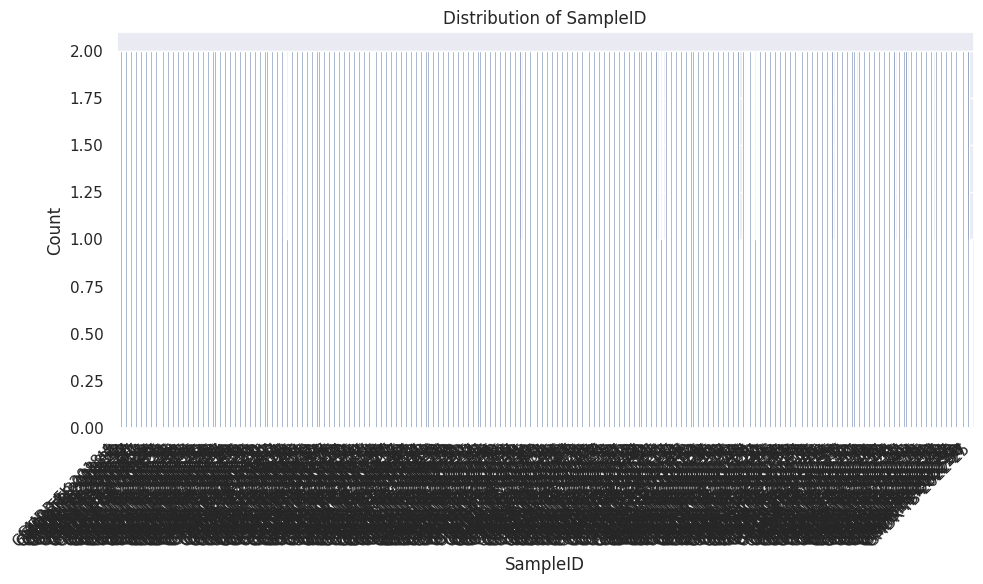

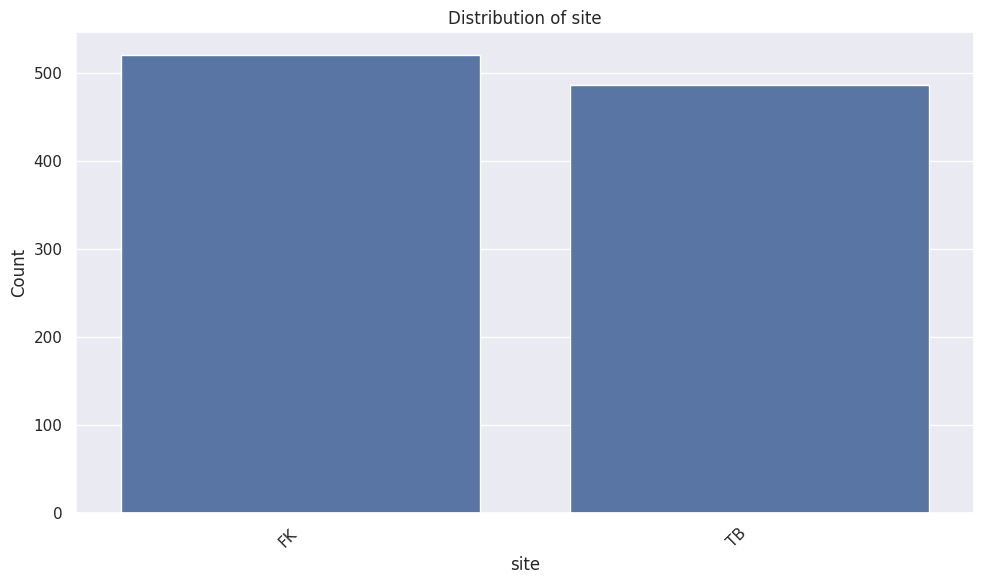

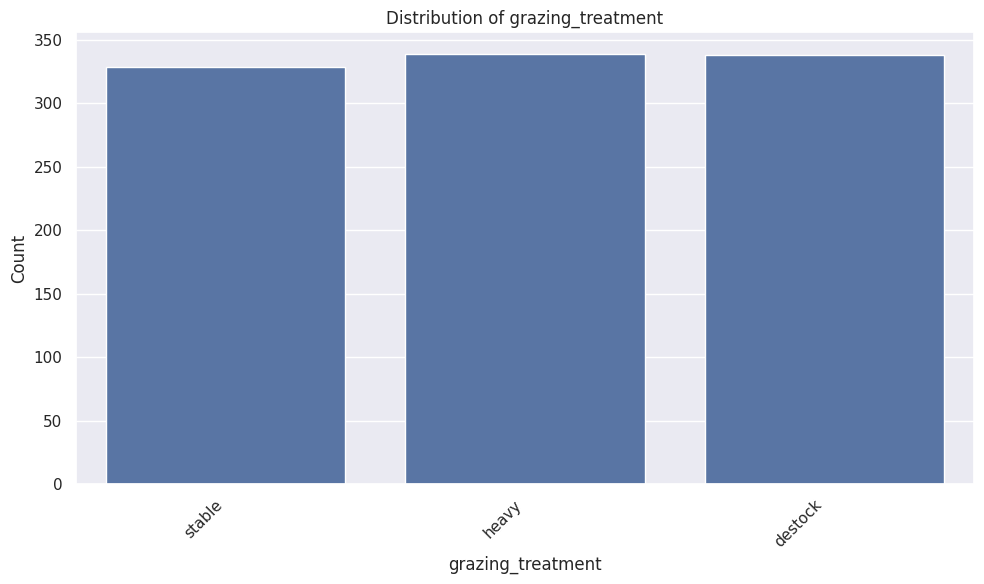

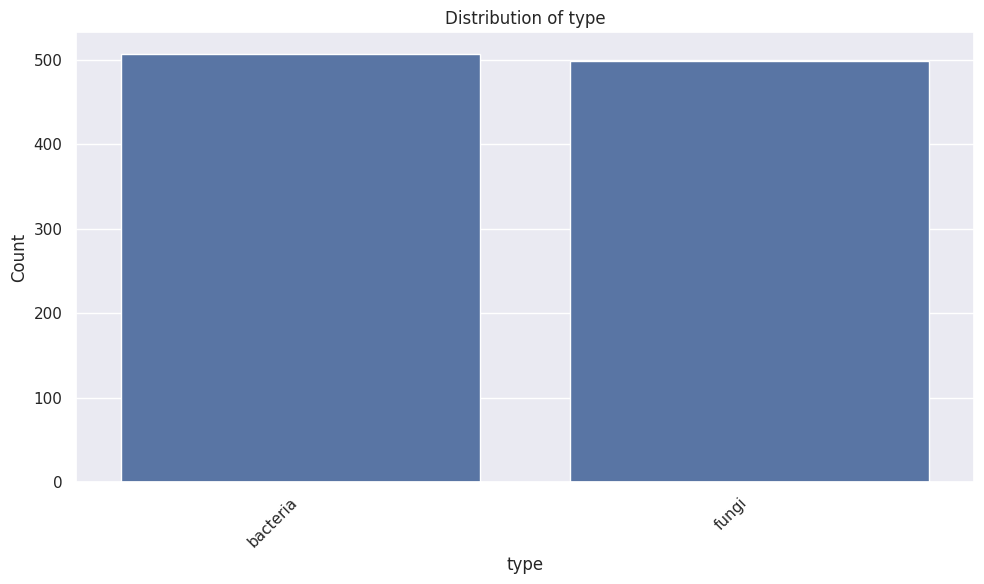

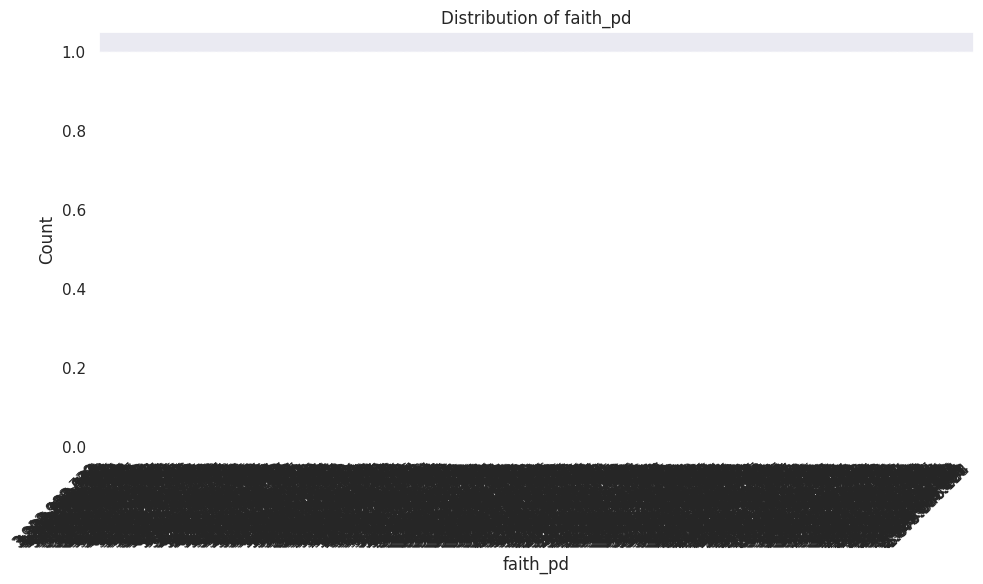

Value counts for SampleID:
SampleID
GMDR-TB-2022-50    2
GMDR-FK-2018-4     2
GMDR-TB-2018-45    2
GMDR-TB-2018-8     2
GMDR-TB-2018-31    2
                  ..
GMDR-TB-2018-54    1
GMDR-FK-2022-21    1
GMDR-FK-2022-7     1
GMDR-TB-2022-27    1
GMDR-TB-2022-25    1
Name: count, Length: 511, dtype: int64

Value counts for site:
site
FK    520
TB    486
Name: count, dtype: int64

Value counts for grazing_treatment:
grazing_treatment
heavy      339
destock    338
stable     329
Name: count, dtype: int64

Value counts for type:
type
bacteria    507
fungi       499
Name: count, dtype: int64

Value counts for faith_pd:
faith_pd
3.077.840.854    1
3.912.908.739    1
3.298.556.468    1
3.332.257.877    1
3.806.342.641    1
                ..
4.144.144.362    1
4.135.907.938    1
4.365.775.764    1
4.047.483.321    1
4.287.060.387    1
Name: count, Length: 1006, dtype: int64



In [15]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

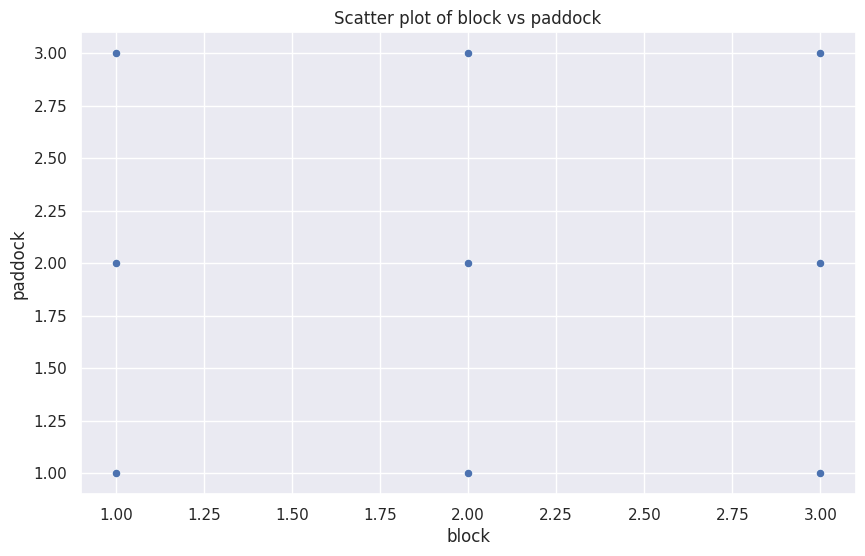

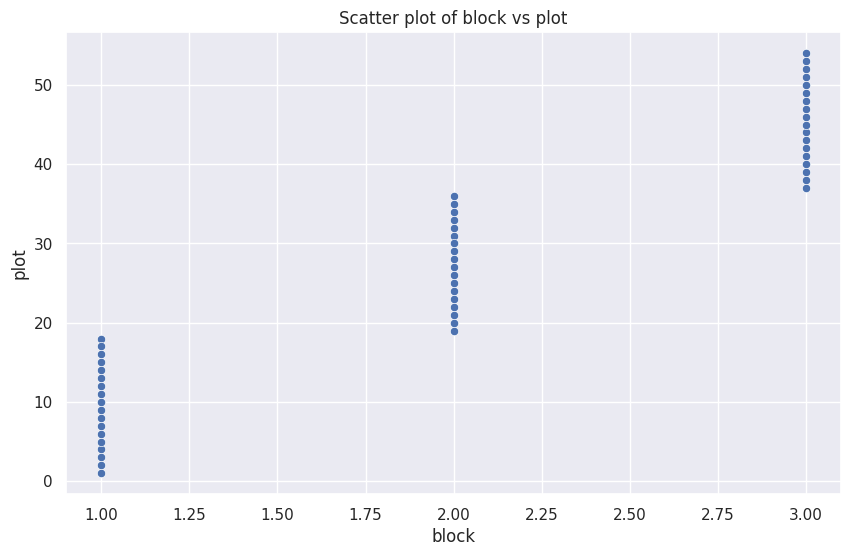

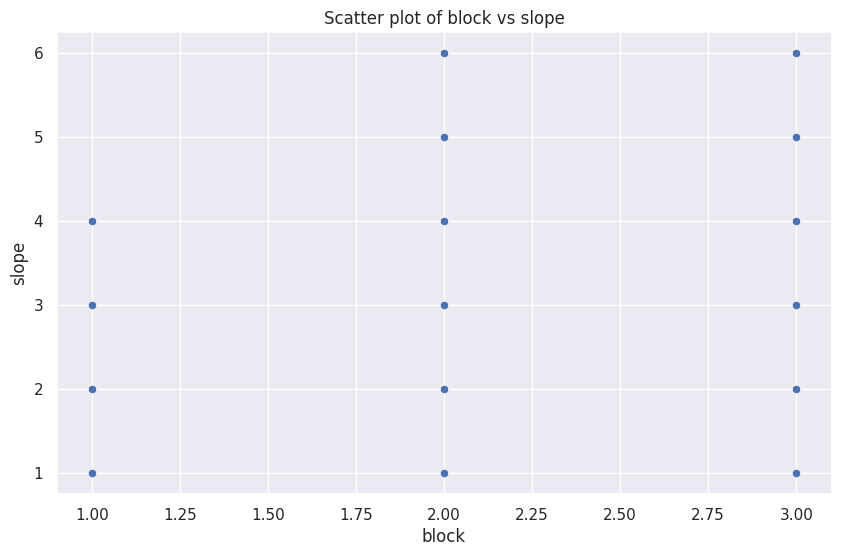

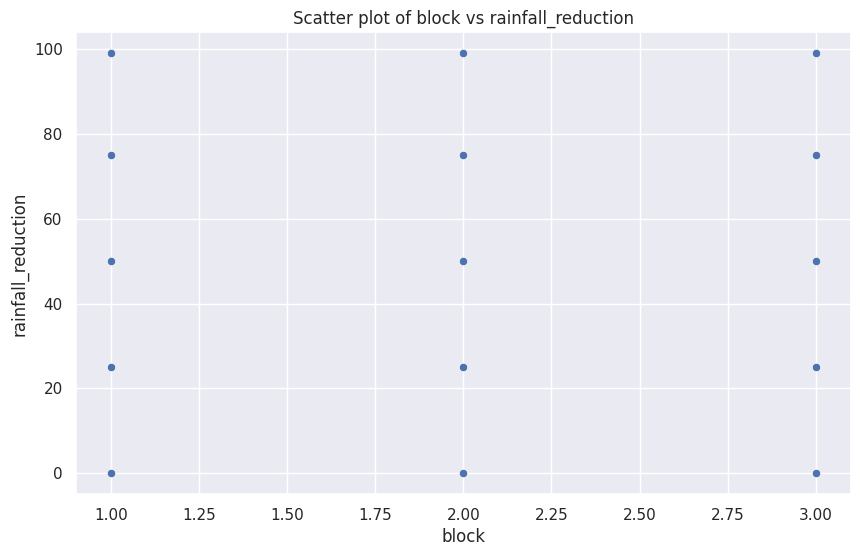

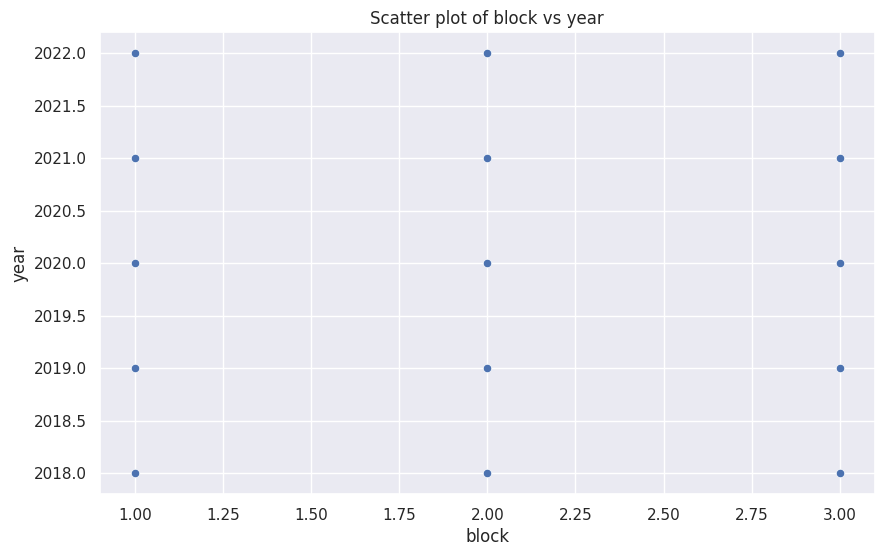

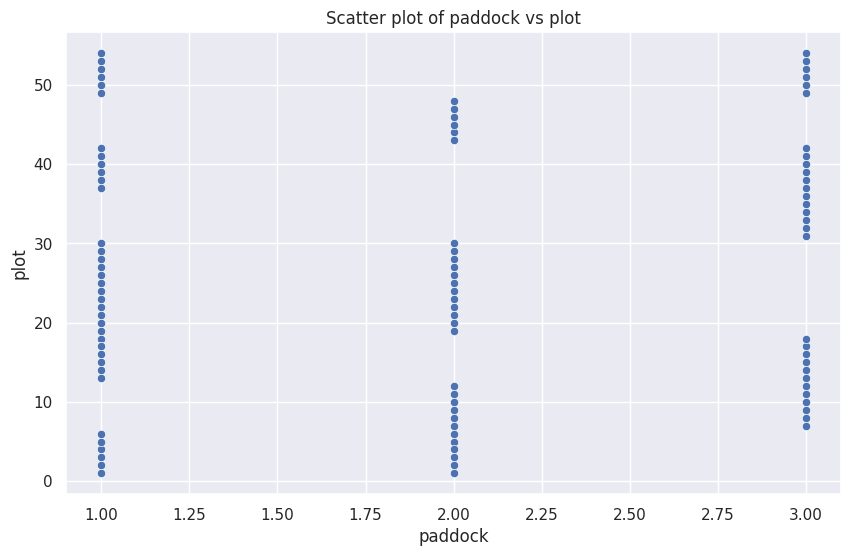

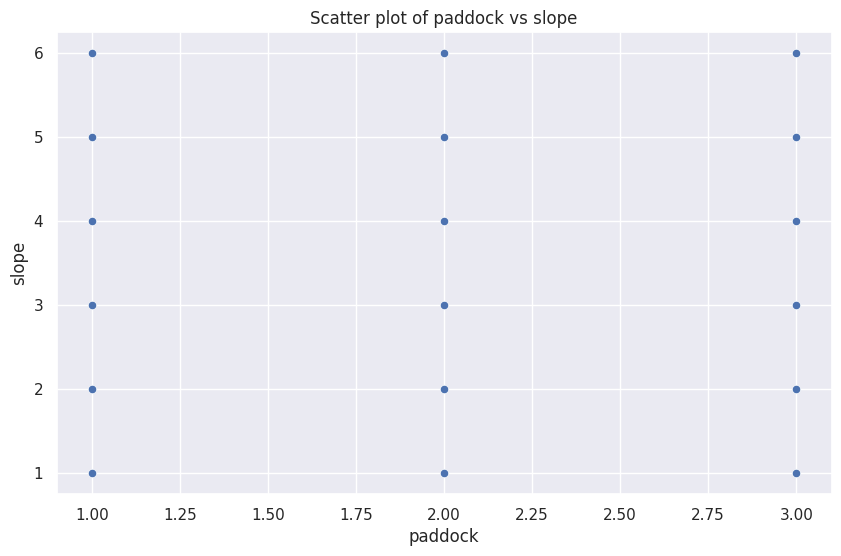

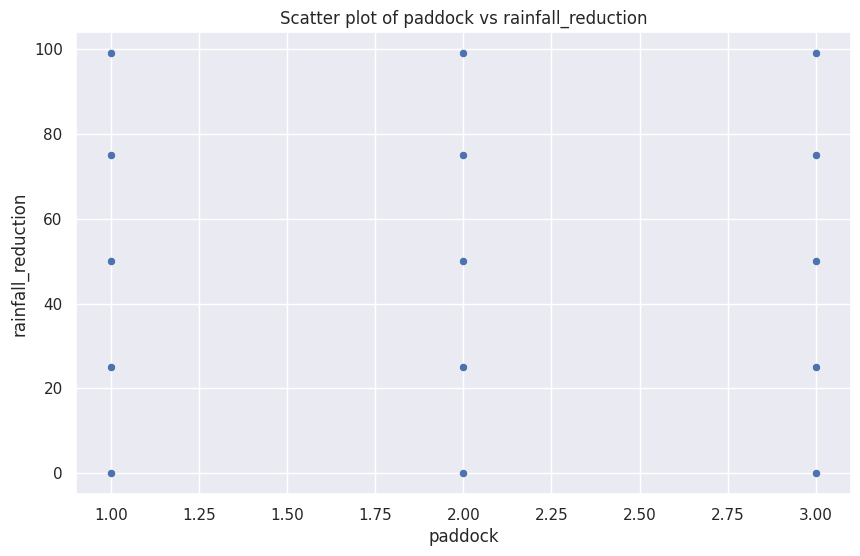

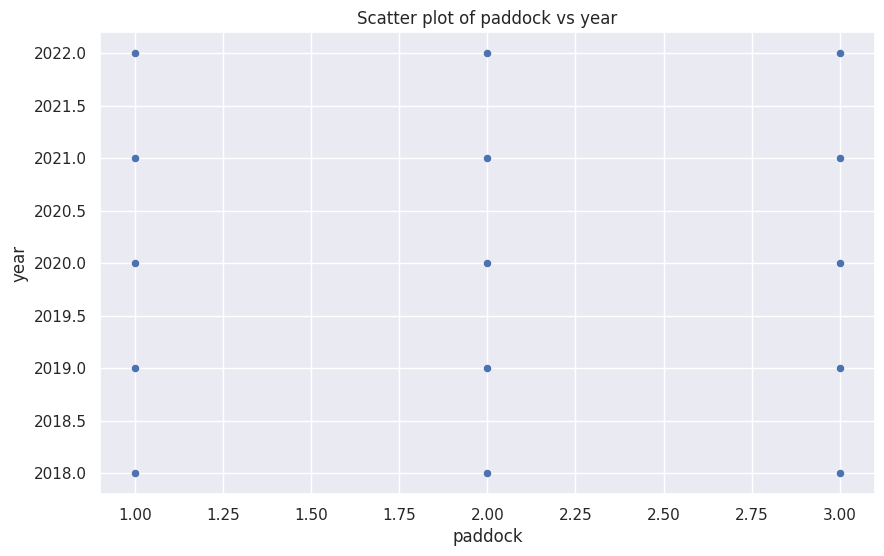

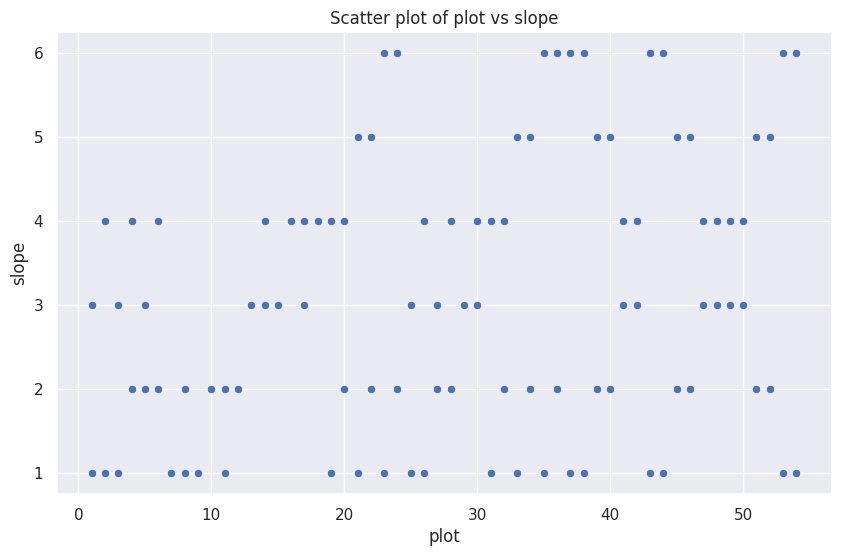

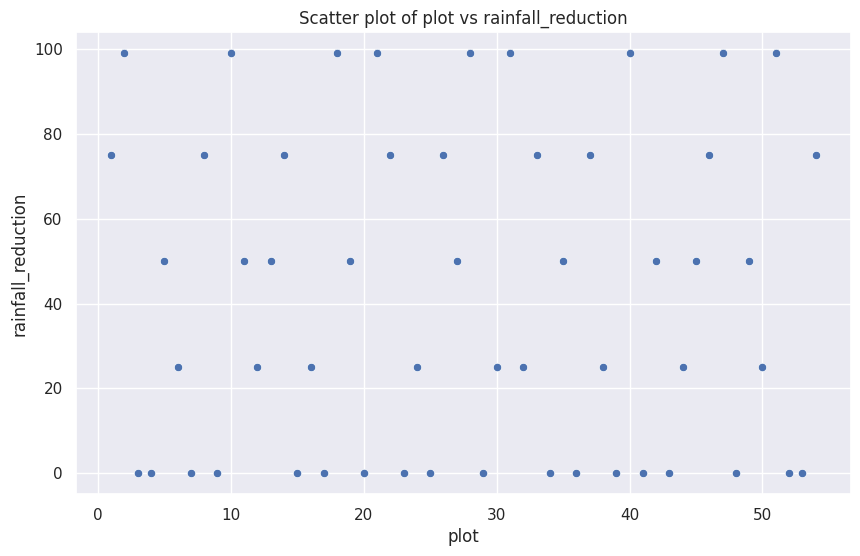

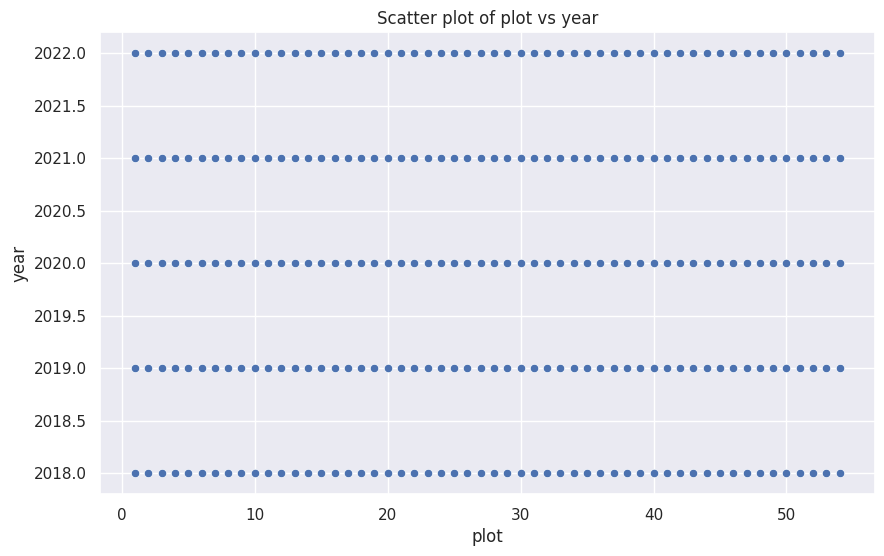

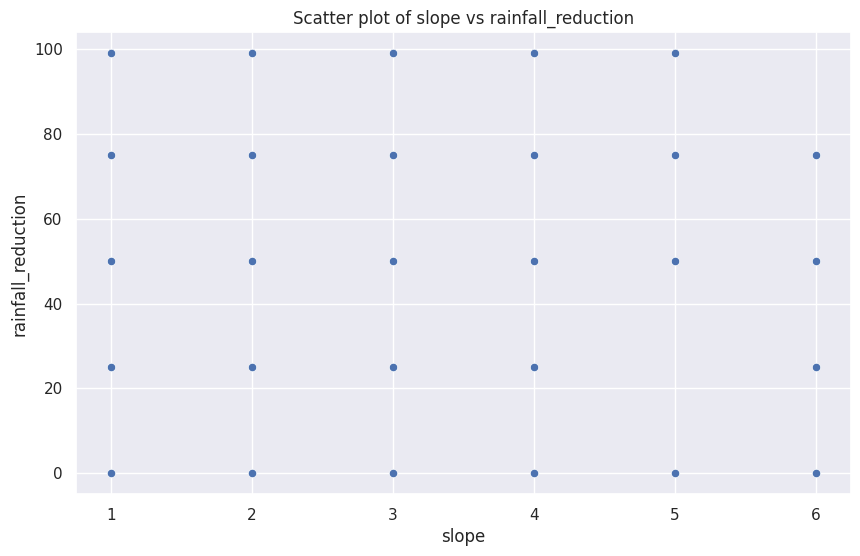

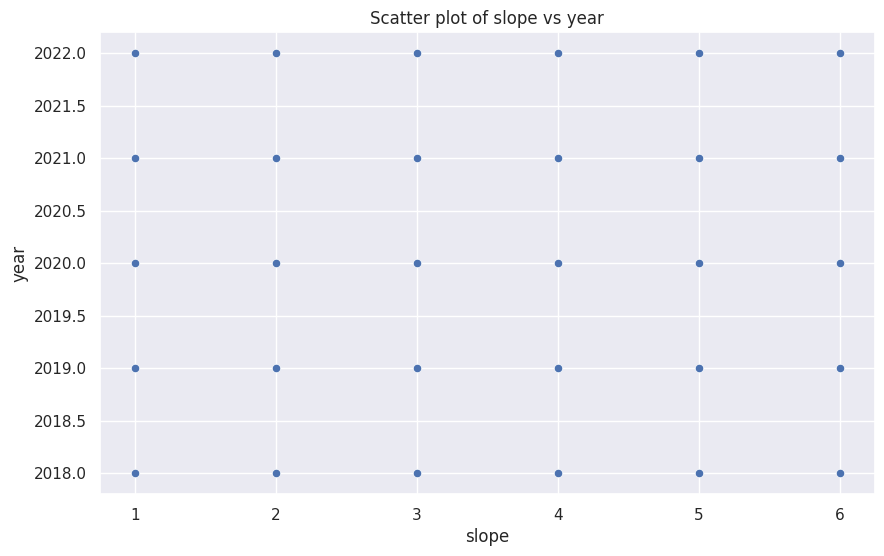

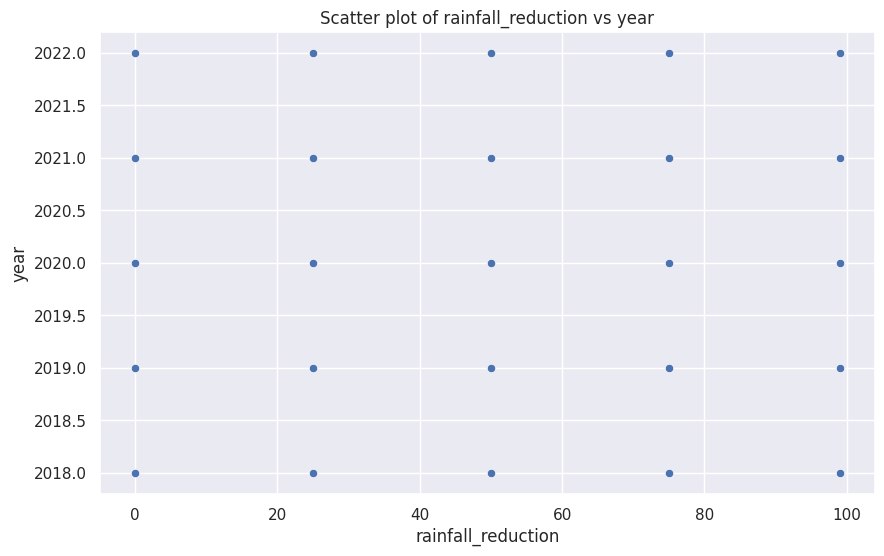

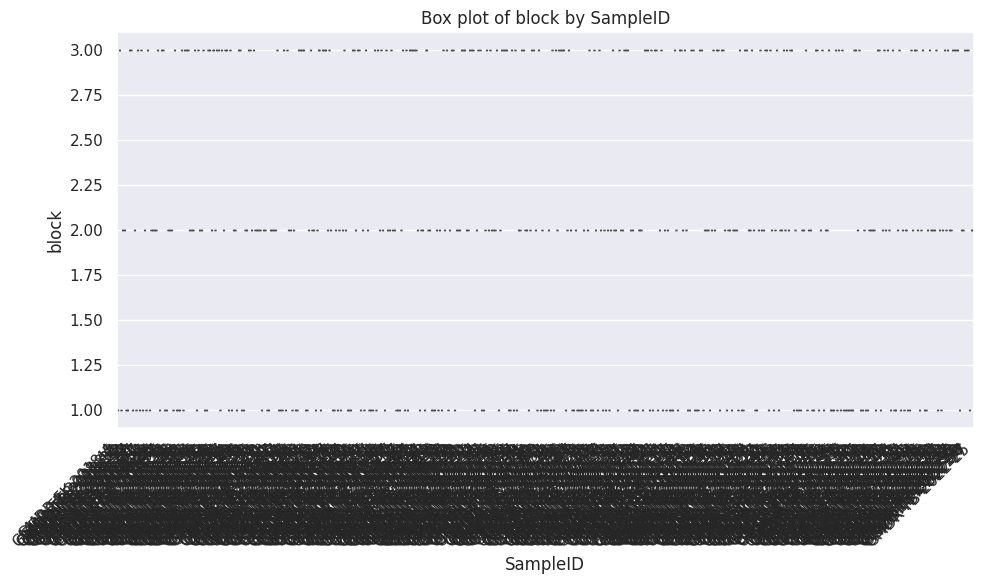

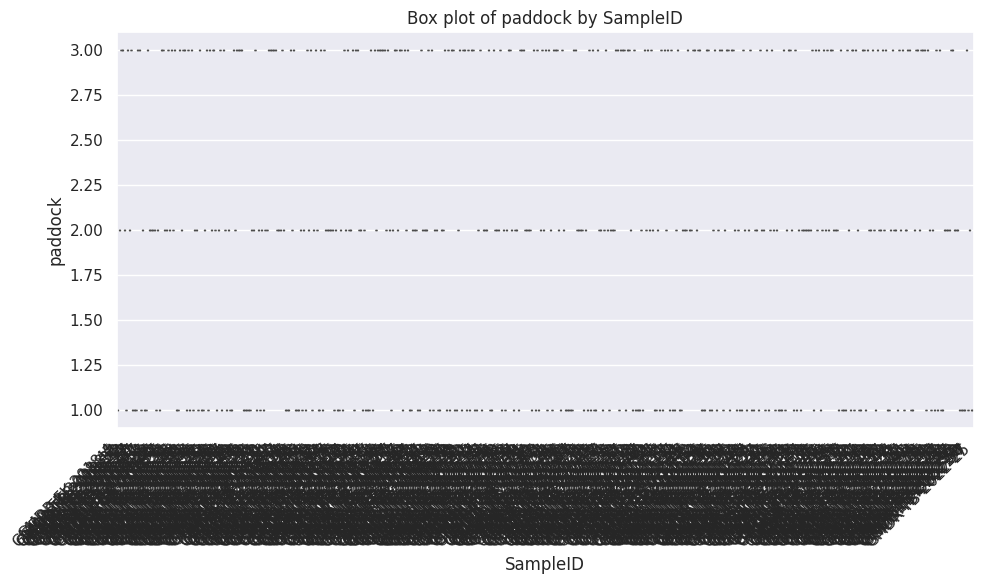

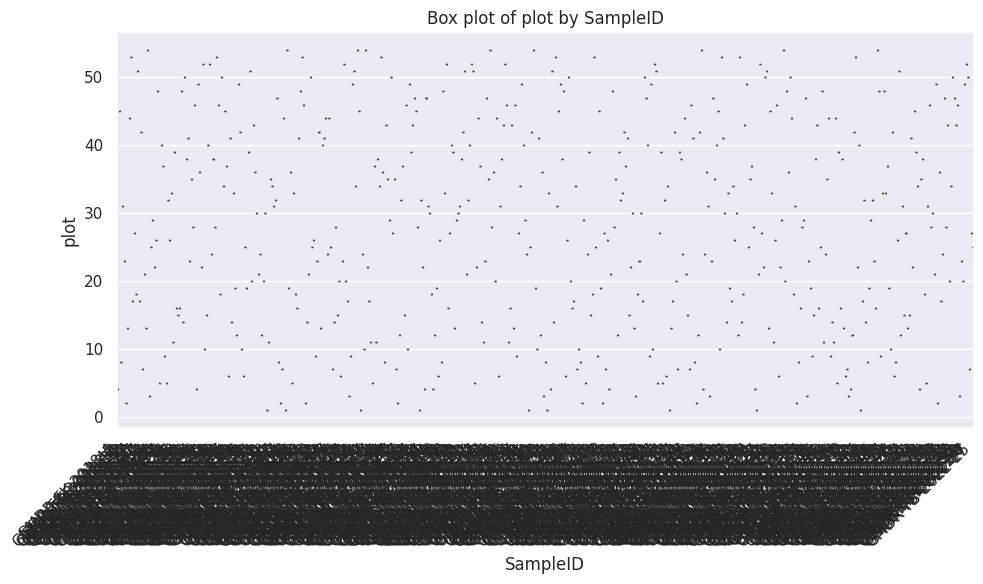

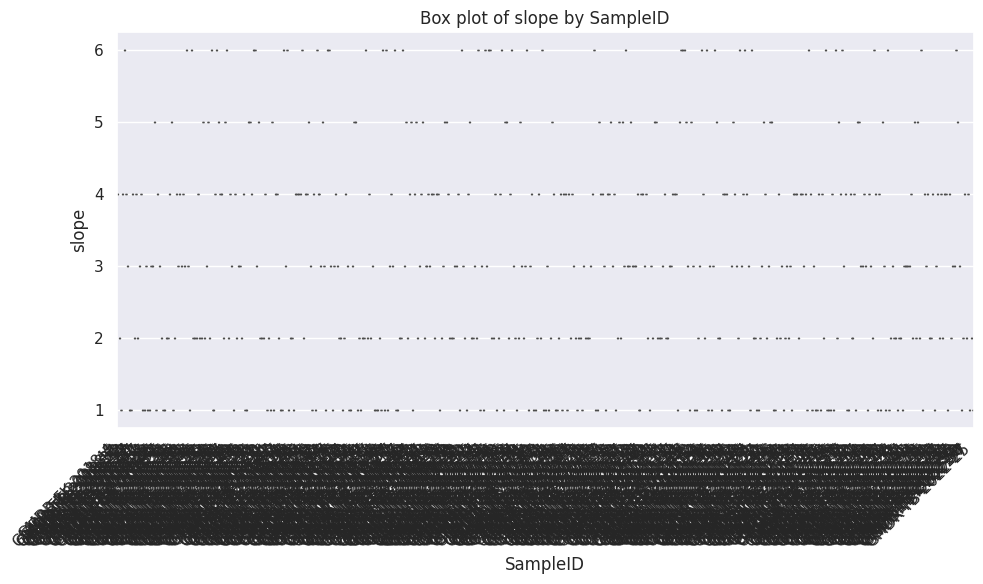

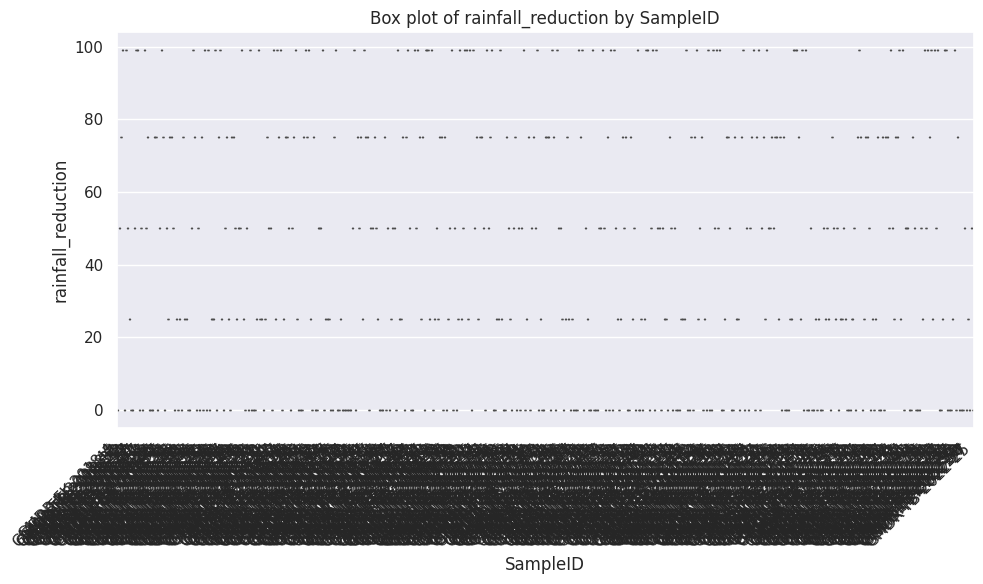

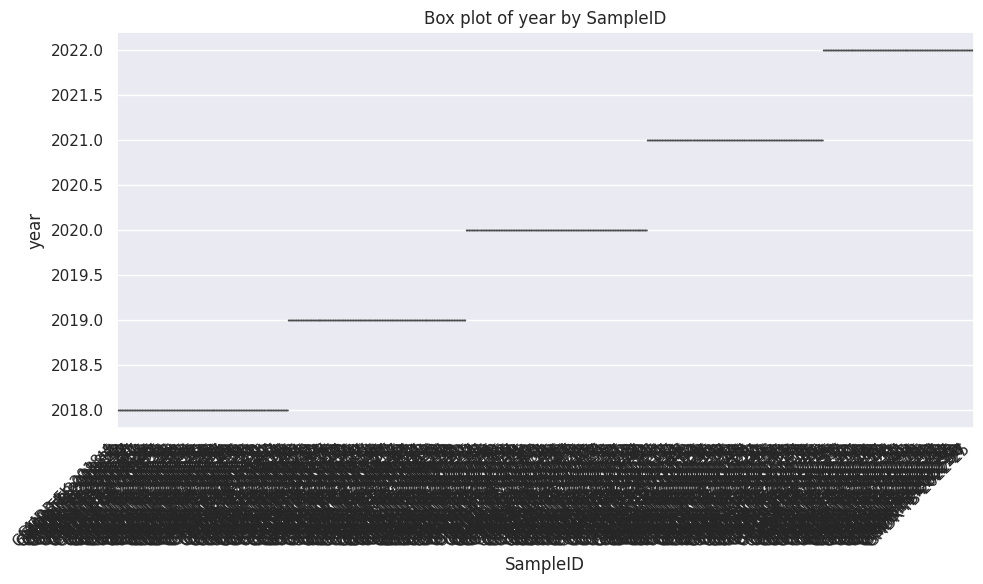

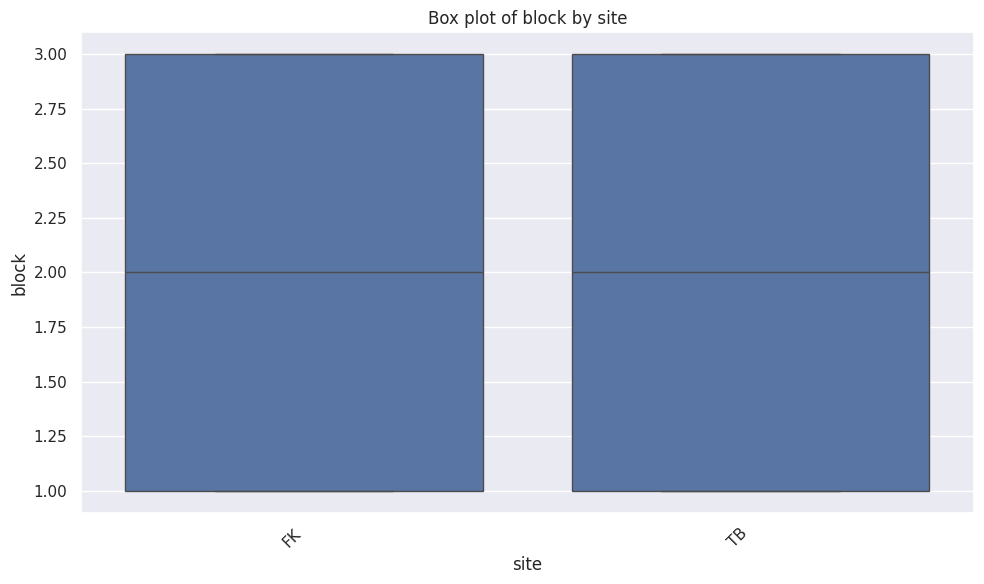

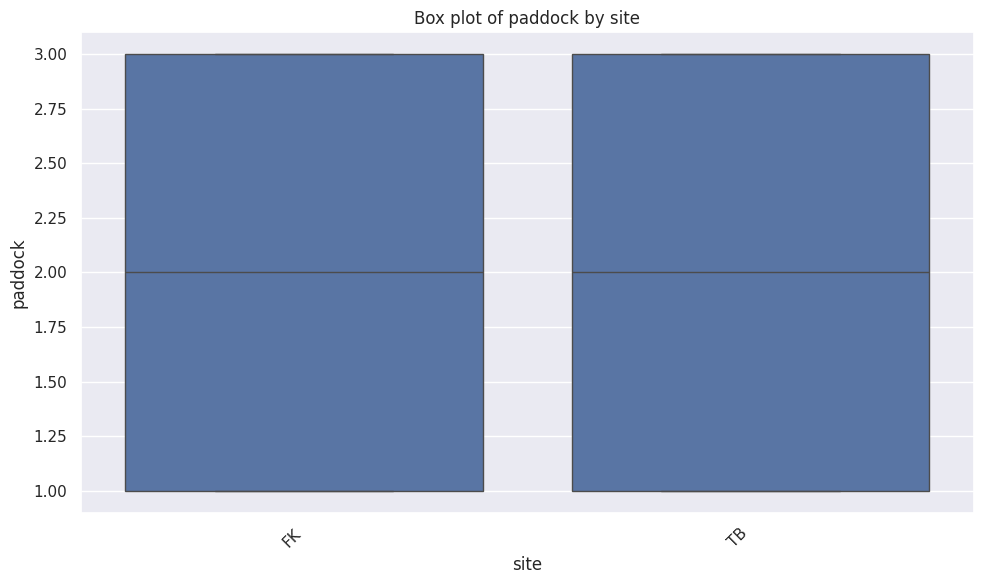

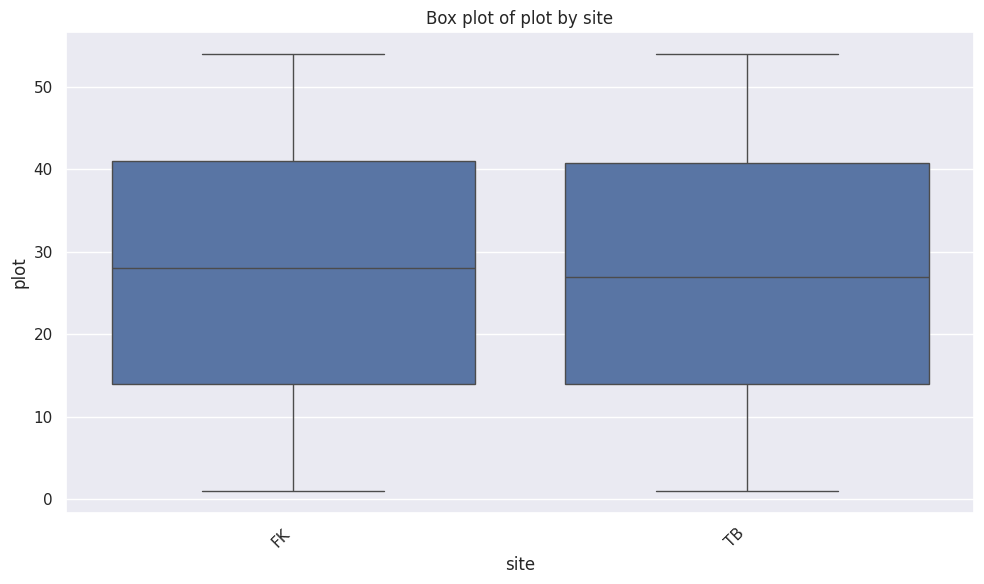

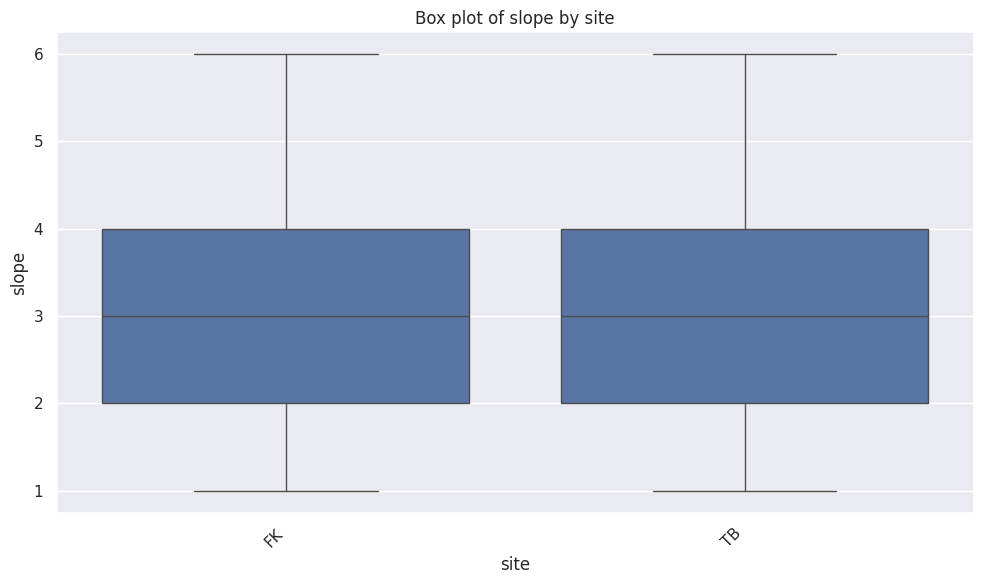

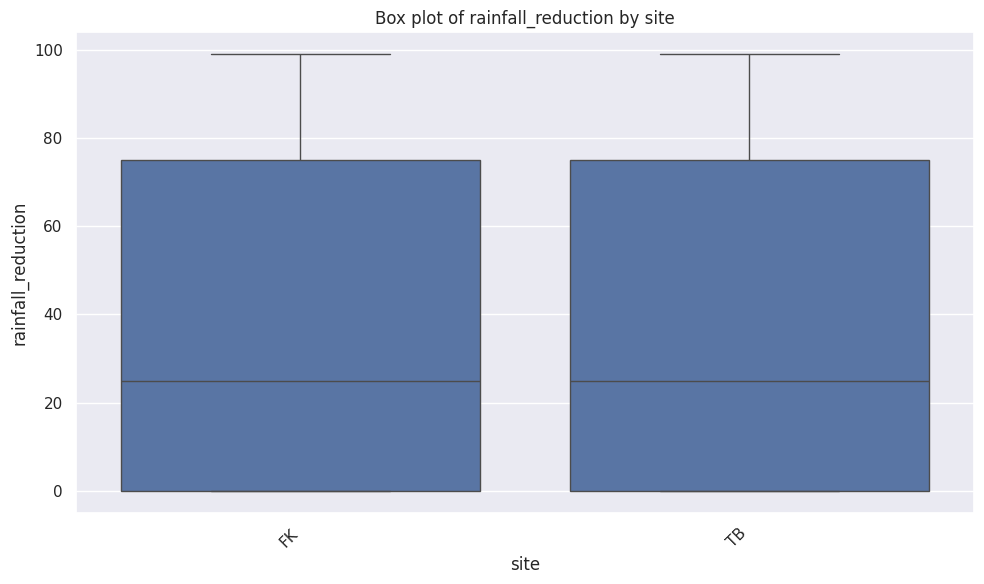

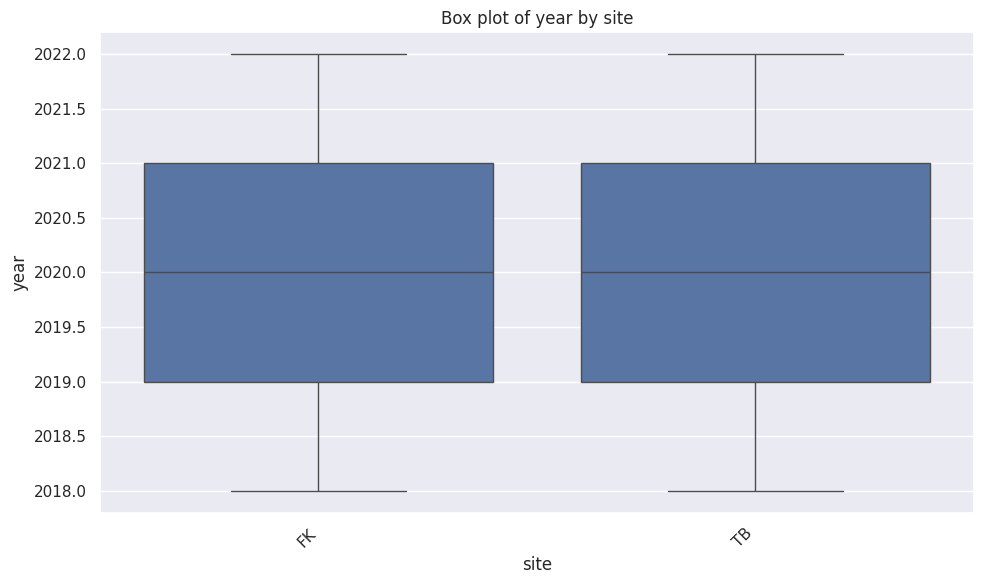

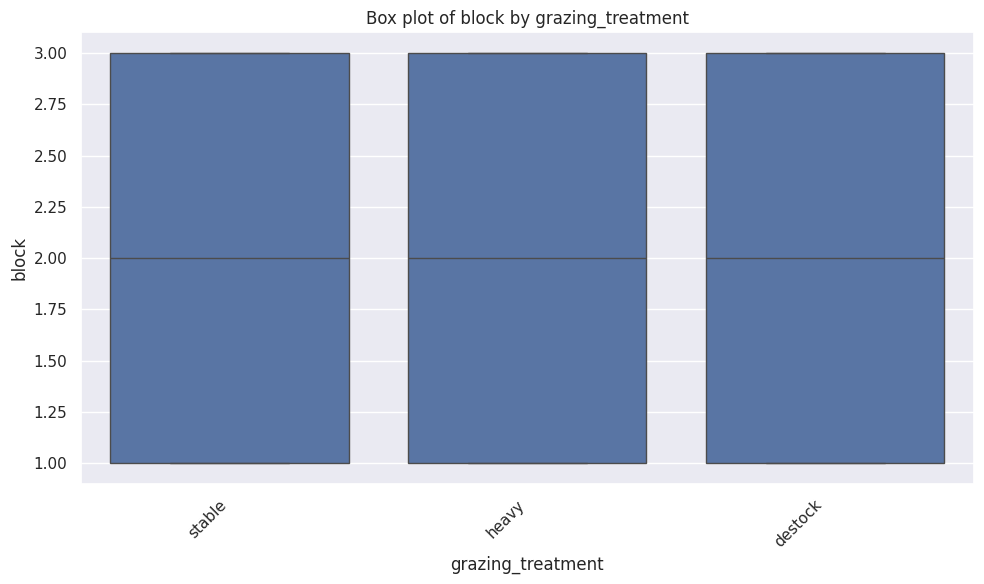

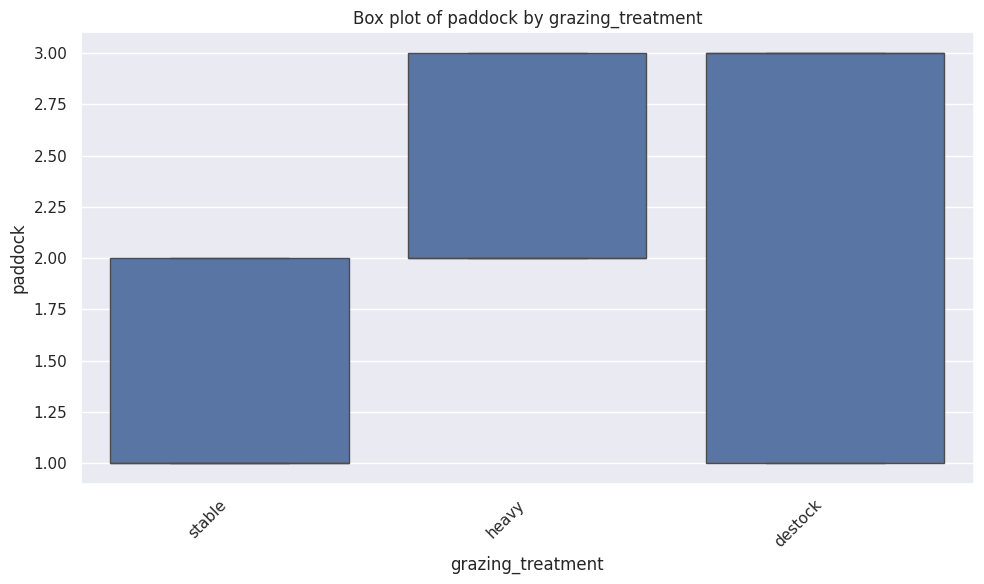

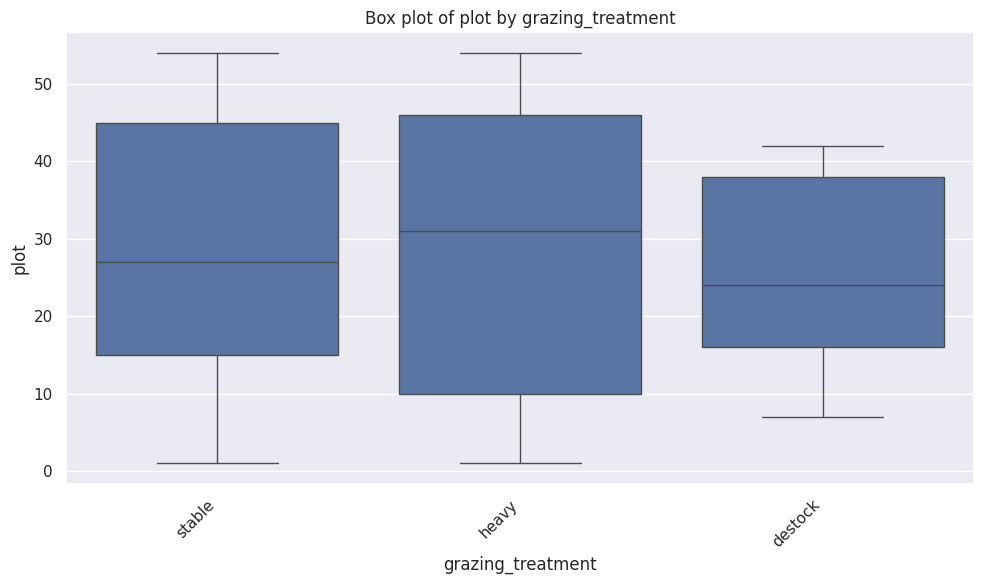

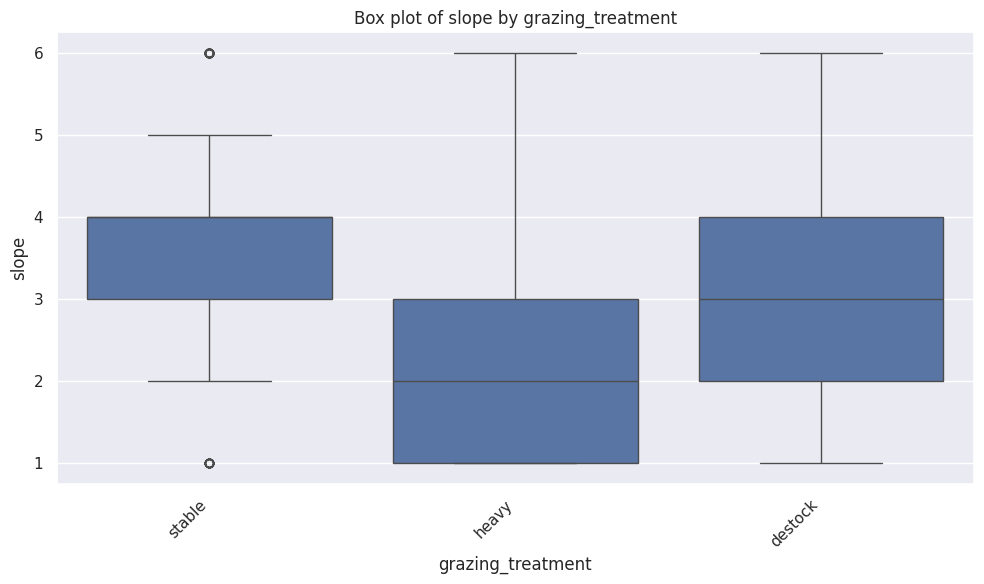

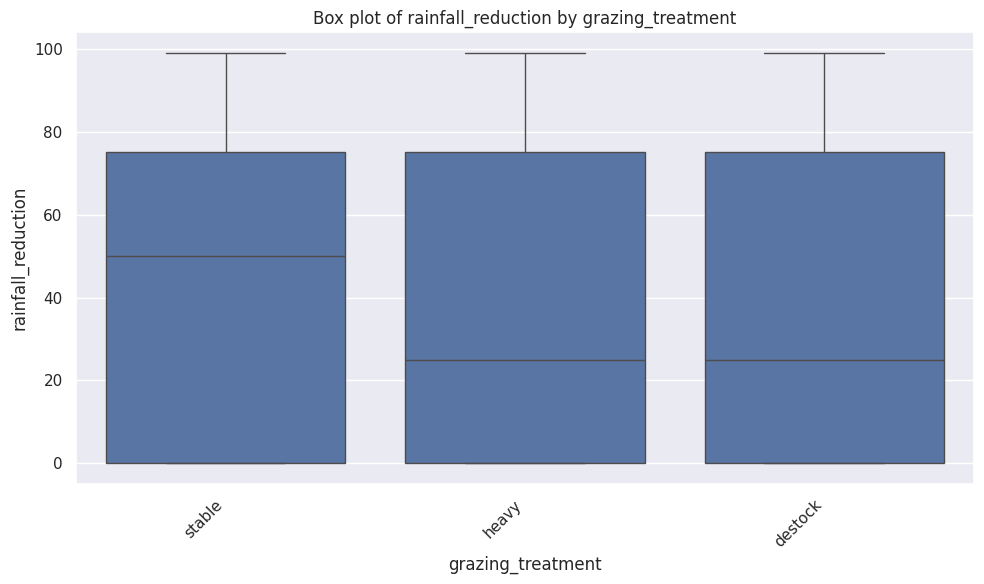

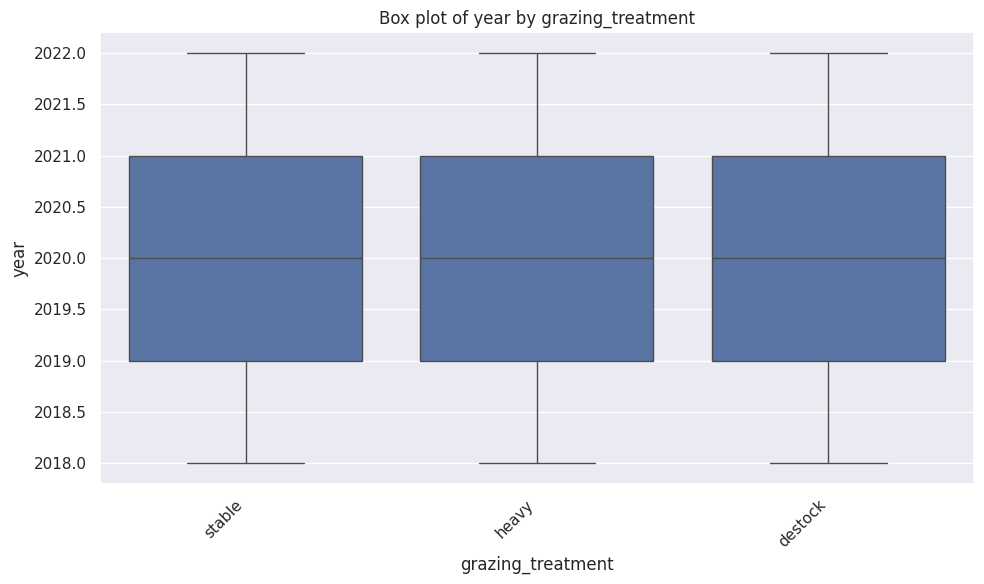

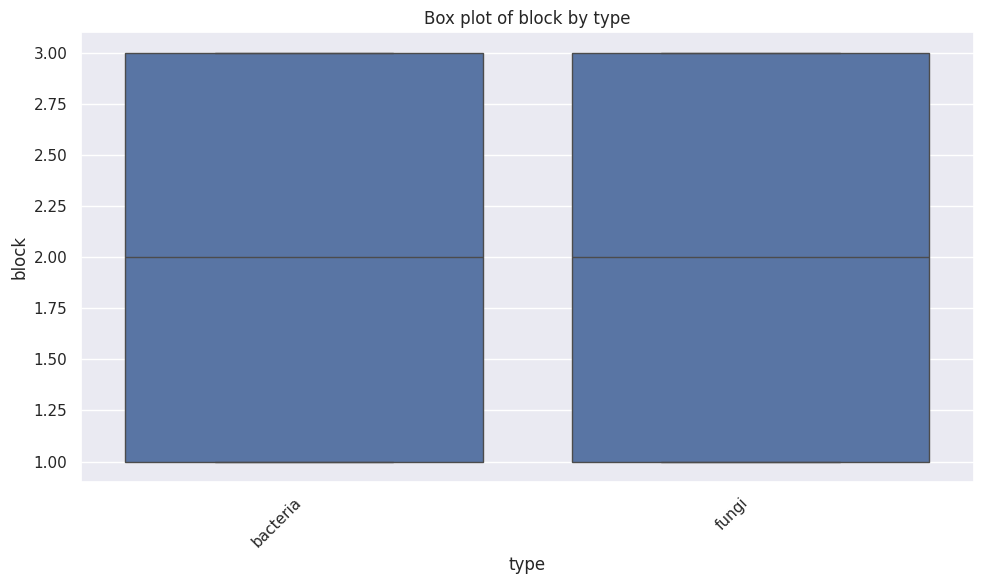

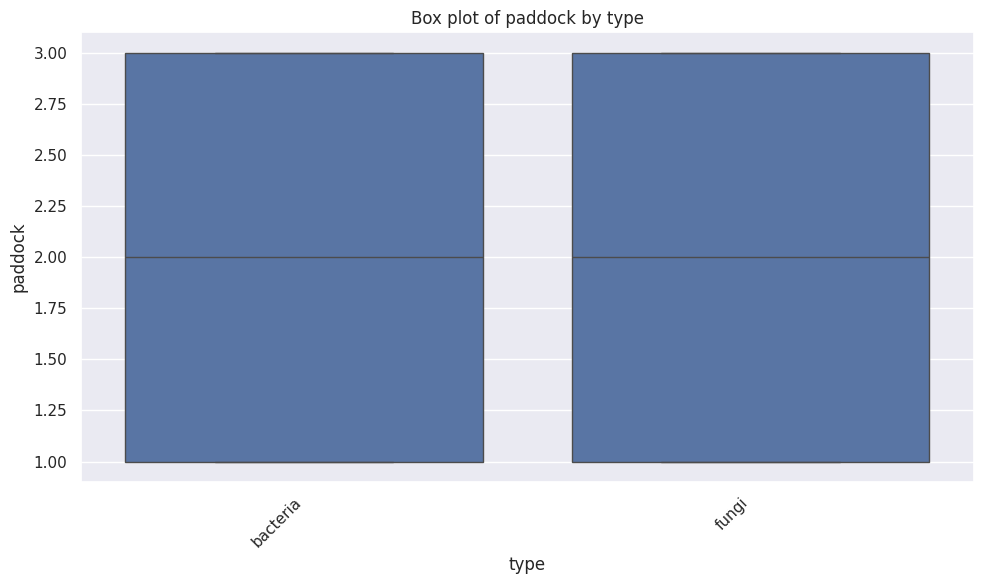

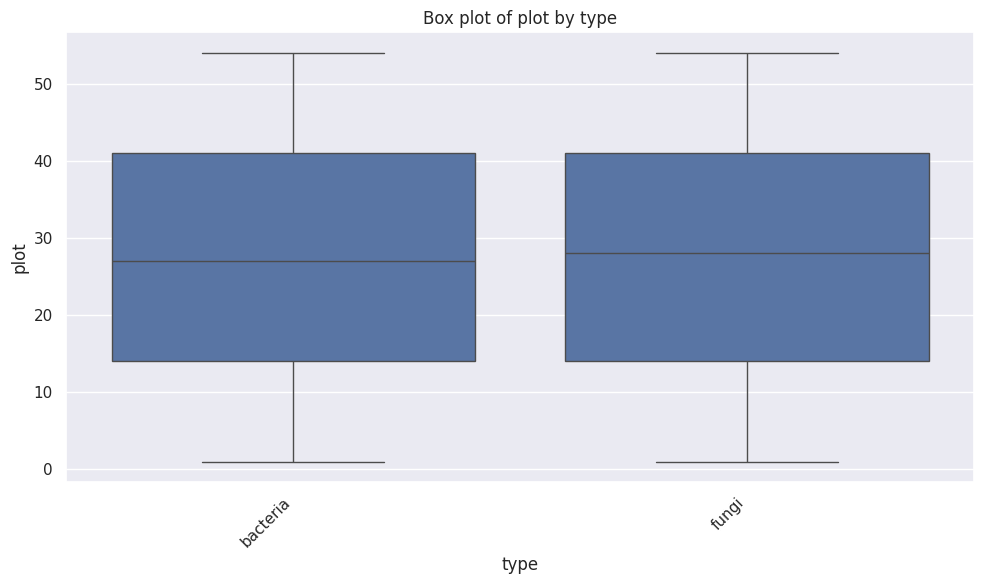

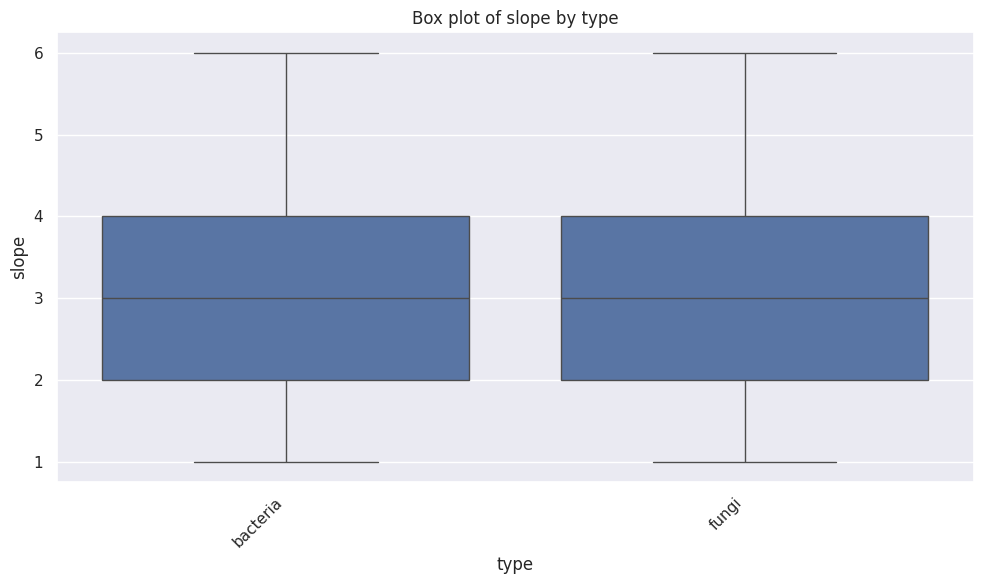

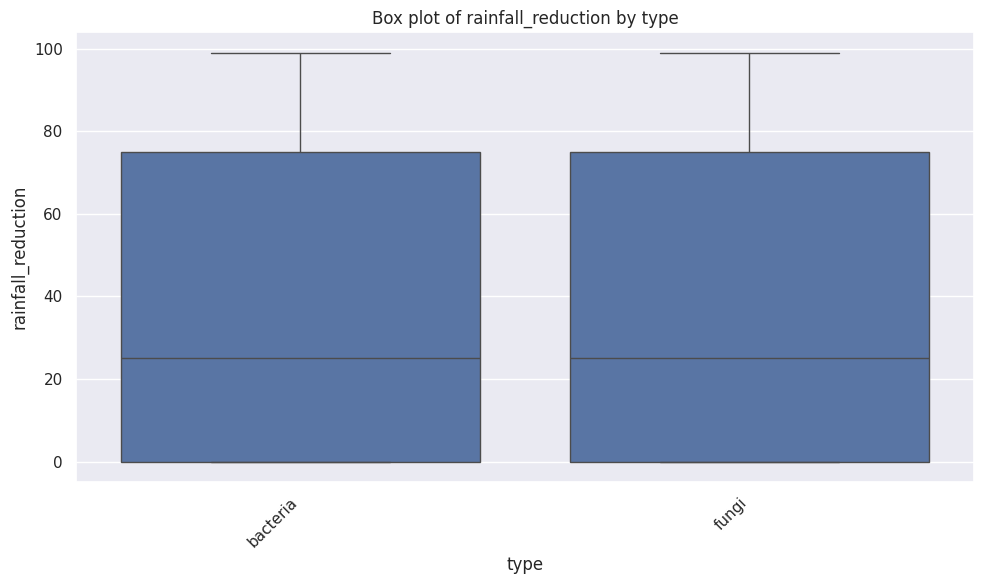

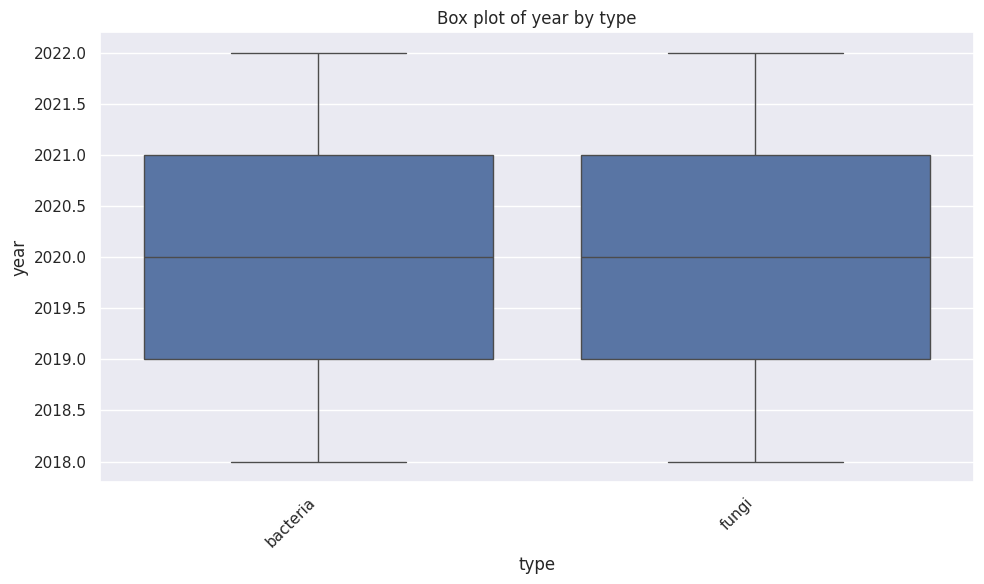

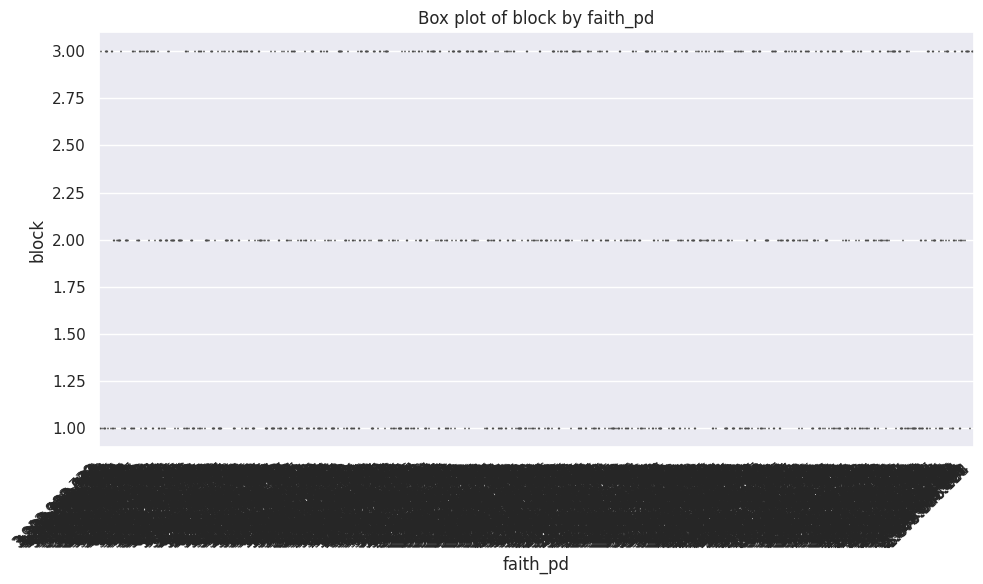

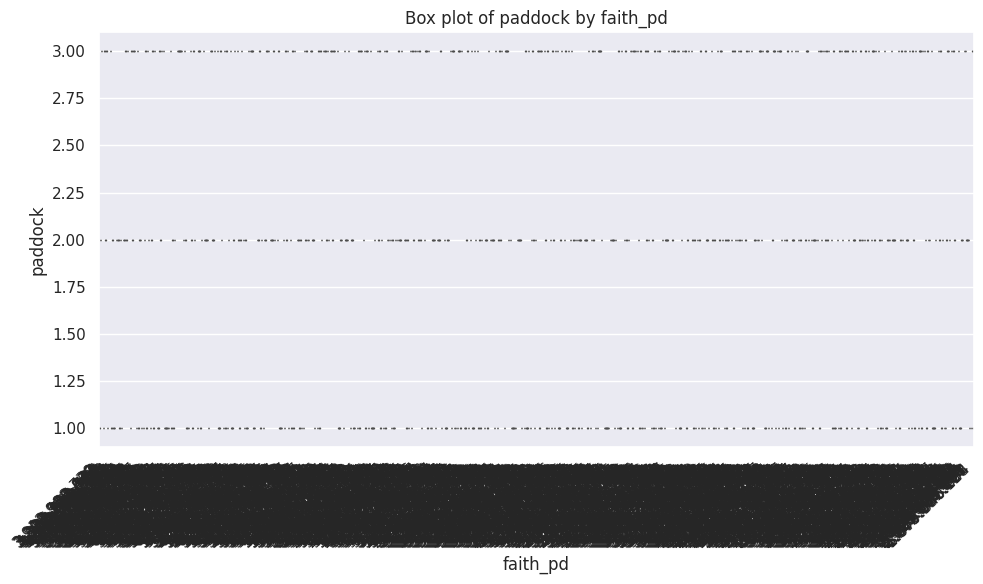

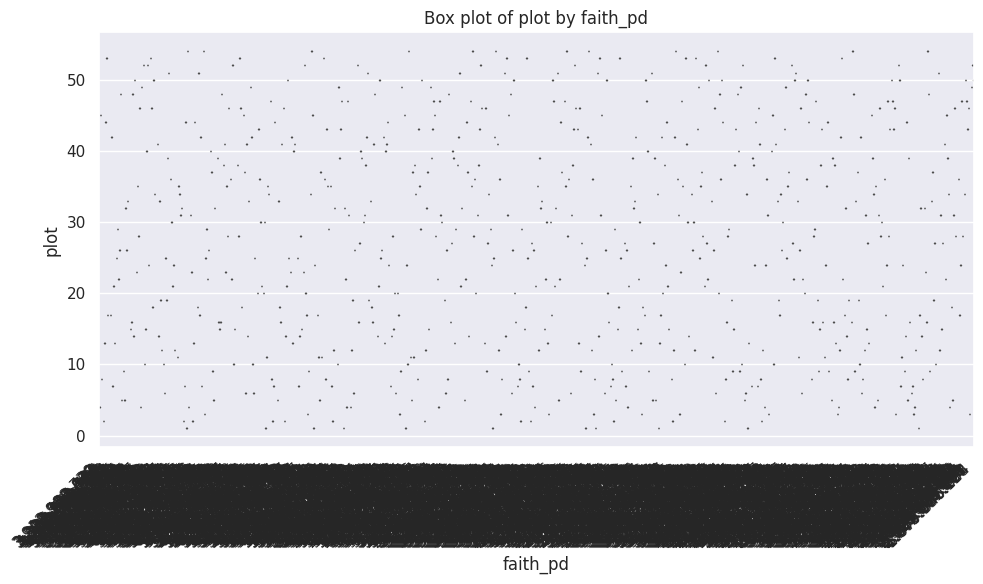

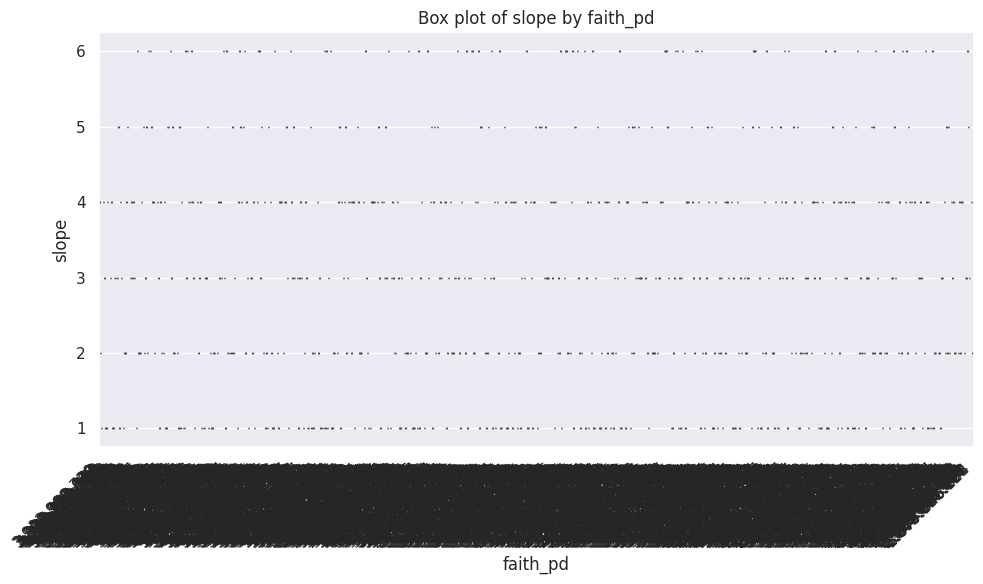

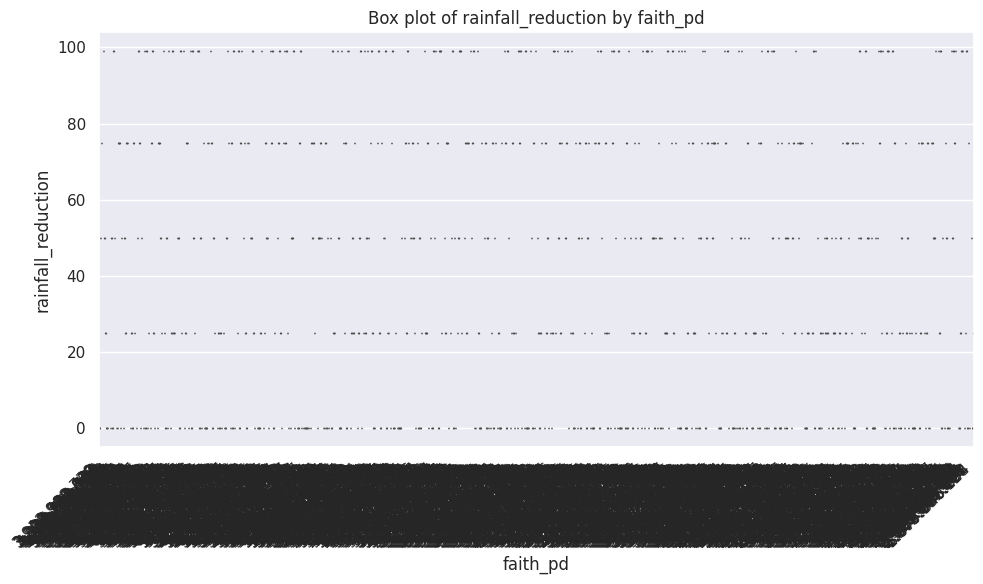

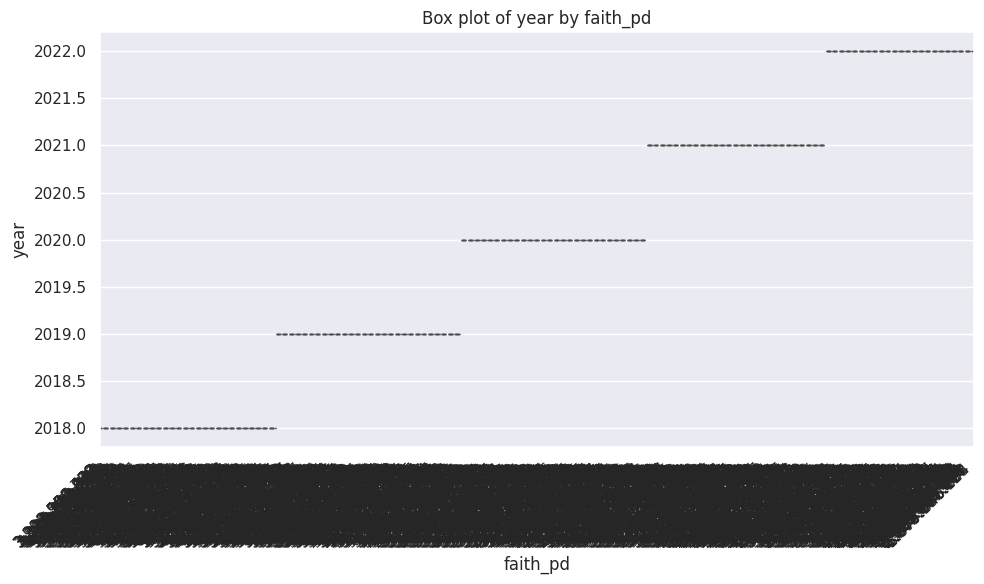

In [16]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

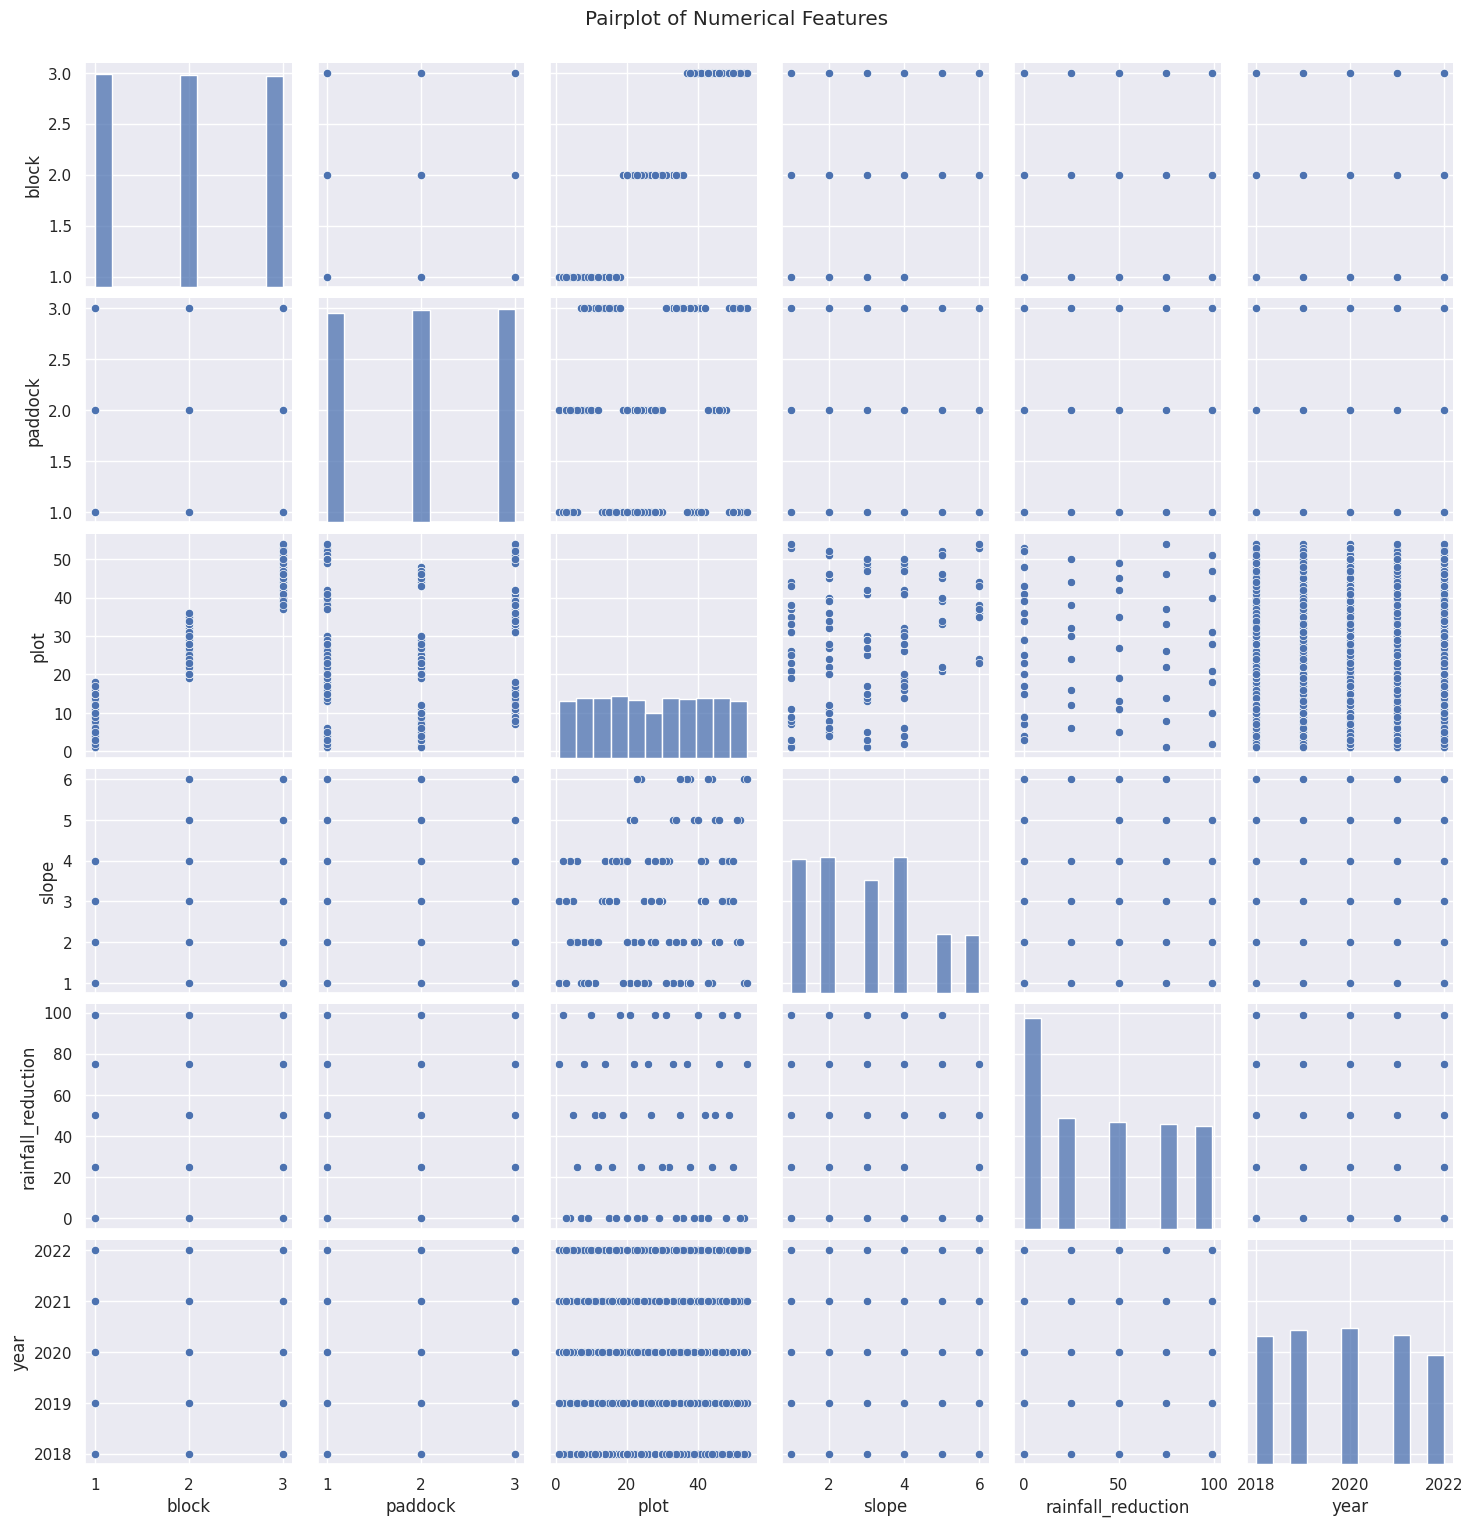

In [17]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

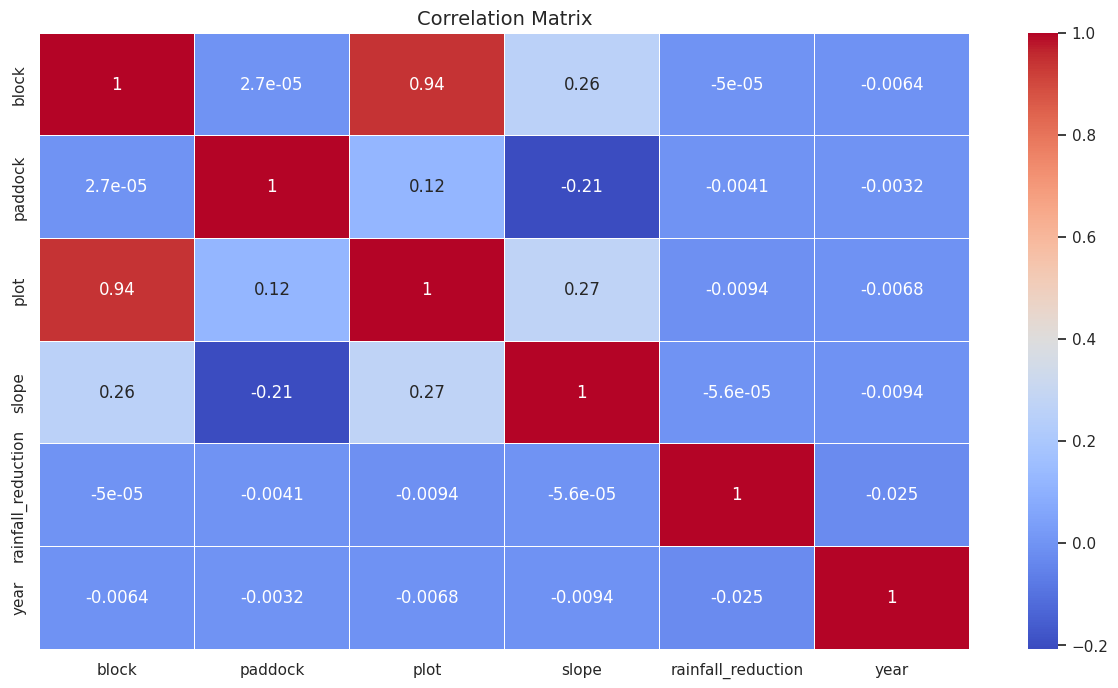

In [18]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You